# Comparative Analysis: KF · EKF · UKF · PF

Dissertation simulation figures for three scenarios.

| Filter | Source notebook |
|--------|----------------|
| **KF** | `kalman_filter.ipynb` |
| **EKF** | `ekf_experimentation.ipynb` |
| **UKF** | `ukf_experimentation.ipynb` |
| **PF** | `pf_experimentation.ipynb` |

**State convention throughout:** `[px, py, vx, vy]`
**Colour scheme:** KF = blue · EKF = orange · UKF = green · PF = red

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
from scipy.stats import chi2, t as t_dist
import os

os.makedirs('figures', exist_ok=True)

FS = 20          # universal font size
FS_LEG = 16      # legend (slightly smaller so it fits)
FS_TICK = 18     # tick labels

plt.rcParams.update({
    'font.size':        FS,
    'axes.labelsize':   FS,
    'axes.titlesize':   FS,
    'figure.titlesize': FS + 2,
    'legend.fontsize':  FS_LEG,
    'xtick.labelsize':  FS_TICK,
    'ytick.labelsize':  FS_TICK,
    'lines.linewidth':  2.0,
    'savefig.dpi':      200,
    'savefig.bbox':     'tight',
    'figure.facecolor': 'white',
})

COLORS  = {'KF':'#1f77b4', 'EKF':'#ff7f0e', 'UKF':'#2ca02c', 'PF':'#d62728'}
LSTYLE  = {'KF':'-',       'EKF':'--',       'UKF':'-.',       'PF':':'}
FILTERS = ['KF','EKF','UKF','PF']
N_PF          = 2000   # particles
RMSE_S3S4_YLIM = 33.0  # shared y-axis for S3 and S4 RMSE figures

def legend_handles(extra=None):
    h = [Line2D([0],[0], color=COLORS[f], ls=LSTYLE[f], lw=2.5, label=f)
         for f in FILTERS]
    return (extra or []) + h

np.random.seed(42)

## Filter Implementations
### Shared dynamics

In [2]:
def make_F(dt):
    """CV state-transition matrix. State: [px, py, vx, vy]."""
    return np.array([[1, 0, dt,  0],
                     [0, 1,  0, dt],
                     [0, 0,  1,  0],
                     [0, 0,  0,  1]])

def make_Q(sigma_a2, dt):
    """Discrete white-noise acceleration process-noise covariance."""
    return sigma_a2 * np.array([
        [dt**4/4,       0, dt**3/2,       0],
        [      0, dt**4/4,       0, dt**3/2],
        [dt**3/2,       0,   dt**2,       0],
        [      0, dt**3/2,       0,   dt**2]])

H_CART = np.array([[1,0,0,0],[0,1,0,0]])   # observe (px, py)

### Kalman Filter — `kalman_filter.ipynb`

In [3]:
def kf_predict(x, P, F, Q):
    return F @ x, F @ P @ F.T + Q

def kf_update(x_pred, P_pred, z, H, R):
    y   = z - H @ x_pred
    S   = H @ P_pred @ H.T + R
    K   = P_pred @ H.T @ np.linalg.inv(S)
    x_u = x_pred + K @ y
    P_u = (np.eye(len(x_pred)) - K @ H) @ P_pred
    P_u = 0.5*(P_u + P_u.T)
    return x_u, P_u, float(y @ np.linalg.solve(S, y))

### Extended Kalman Filter — `ekf_experimentation.ipynb`

In [4]:
def ekf_predict(x, P, F, Q):
    """CV predict — Jacobian of F equals F for linear dynamics."""
    return F @ x, F @ P @ F.T + Q

# --- range-bearing measurement model ---
def h_rb(x):
    """h : [px,py,vx,vy] → [r, θ]."""
    return np.array([np.hypot(x[0],x[1]), np.arctan2(x[1],x[0])])

def H_rb_jac(x):
    """2×4 Jacobian of h_rb."""
    px,py = x[0],x[1]; r=np.hypot(px,py); r2=r**2
    return np.array([[ px/r,  py/r, 0, 0],
                     [-py/r2, px/r2, 0, 0]])

def ekf_update_rb(x_pred, P_pred, z, R):
    H     = H_rb_jac(x_pred)
    inn   = z - h_rb(x_pred)
    inn[1]= (inn[1]+np.pi)%(2*np.pi)-np.pi
    S     = H @ P_pred @ H.T + R
    K     = P_pred @ H.T @ np.linalg.inv(S)
    x_u   = x_pred + K @ inn
    P_u   = 0.5*((np.eye(4)-K@H)@P_pred); P_u=P_u+P_u.T
    return x_u, P_u, float(inn @ np.linalg.inv(S) @ inn)

# --- linear Cartesian measurement (Scenarios 1 & 3) ---
def ekf_update_cartesian(x_pred, P_pred, z, H, R):
    y   = z - H @ x_pred
    S   = H @ P_pred @ H.T + R
    K   = P_pred @ H.T @ np.linalg.inv(S)
    x_u = x_pred + K @ y
    P_u = 0.5*((np.eye(4)-K@H)@P_pred); P_u=P_u+P_u.T
    return x_u, P_u, float(y @ np.linalg.solve(S, y))
# --- CTRV dynamics (Scenario 2) ---
def ctrv_f(x, dt, omega):
    px,py,vx,vy = x
    ct=np.cos(omega*dt); st=np.sin(omega*dt)
    return np.array([px+vx*dt, py+vy*dt, vx*ct-vy*st, vx*st+vy*ct])

def ctrv_F_jac(x, dt, omega):
    ct=np.cos(omega*dt); st=np.sin(omega*dt)
    return np.array([[1,0,dt,0],[0,1,0,dt],
                     [0,0,ct,-st],[0,0,st,ct]])

def ekf_predict_ctrv(x, P, Q, dt, omega):
    F = ctrv_F_jac(x, dt, omega)
    return ctrv_f(x, dt, omega), F @ P @ F.T + Q


### Unscented Kalman Filter — `ukf_experimentation.ipynb`

In [5]:
def ukf_weights(n, alpha=1e-3, beta=2.0, kappa=0.0):
    lam   = alpha**2*(n+kappa)-n
    Wm    = np.full(2*n+1, 0.5/(n+lam)); Wc=Wm.copy()
    Wm[0] = lam/(n+lam); Wc[0]=lam/(n+lam)+(1-alpha**2+beta)
    return Wm, Wc, lam

def ukf_sigma_points(x, P, lam):
    n=len(x); L=np.linalg.cholesky((n+lam)*P)
    sig=np.empty((2*n+1,n)); sig[0]=x
    for i in range(n):
        sig[i+1]=x+L[:,i]; sig[n+i+1]=x-L[:,i]
    return sig

def ukf_predict(x, P, Q, F, Wm, Wc, lam):
    """Predict for linear CV dynamics via sigma points."""
    sig=ukf_sigma_points(x,P,lam); sig_f=(F@sig.T).T
    xp=Wm@sig_f; d=sig_f-xp
    Pp=Q+(d*Wc[:,None]).T@d
    return xp, Pp, sig_f

def ukf_update_rb(xp, Pp, sig_f, z, R, Wm, Wc):
    """Update with nonlinear range-bearing h — no Jacobian."""
    sig_h=np.array([h_rb(s) for s in sig_f]); zp=Wm@sig_h
    dz=sig_h-zp; dx=sig_f-xp
    S=R+(dz*Wc[:,None]).T@dz; Pxz=(dx*Wc[:,None]).T@dz
    K=Pxz@np.linalg.inv(S)
    inn=z-zp; inn[1]=(inn[1]+np.pi)%(2*np.pi)-np.pi
    xu=xp+K@inn; Pu=0.5*(Pp-K@S@K.T); Pu=Pu+Pu.T
    return xu, Pu, float(inn@np.linalg.inv(S)@inn)

def ukf_update_cartesian(xp, Pp, sig_f, z, H, R, Wm, Wc):
    """Update with linear Cartesian h."""
    sig_h=(H@sig_f.T).T; zp=Wm@sig_h
    dz=sig_h-zp; dx=sig_f-xp
    S=R+(dz*Wc[:,None]).T@dz; Pxz=(dx*Wc[:,None]).T@dz
    K=Pxz@np.linalg.inv(S); inn=z-zp
    xu=xp+K@inn; Pu=0.5*(Pp-K@S@K.T); Pu=Pu+Pu.T
    return xu, Pu, float(inn@np.linalg.inv(S)@inn)
def ukf_predict_nl(x, P, Q, f_func, Wm, Wc, lam):
    """Predict for nonlinear dynamics (e.g. CTRV) via sigma points."""
    sig=ukf_sigma_points(x,P,lam)
    sig_f=np.array([f_func(s) for s in sig])
    xp=Wm@sig_f; d=sig_f-xp
    Pp=Q+(d*Wc[:,None]).T@d
    return xp, Pp, sig_f


### Particle Filter — `pf_experimentation.ipynb`

In [6]:
def pf_init(N_p, x0_mean, x0_std):
    return (x0_mean + np.random.randn(N_p,4)*x0_std,
            np.ones(N_p)/N_p)

def pf_predict_cv(particles, dt, sigma_a):
    N=len(particles); ax=np.random.randn(N)*sigma_a; ay=np.random.randn(N)*sigma_a
    p=particles.copy()
    p[:,0]=particles[:,0]+particles[:,2]*dt+0.5*ax*dt**2
    p[:,1]=particles[:,1]+particles[:,3]*dt+0.5*ay*dt**2
    p[:,2]=particles[:,2]+ax*dt; p[:,3]=particles[:,3]+ay*dt
    return p

def _nw(w):
    s=w.sum(); return w/s if s>1e-300 else np.ones(len(w))/len(w)

def pf_update_cartesian(particles, weights, z, R):
    inn=z-particles[:,:2]; Ri=np.linalg.inv(R)
    lw=-0.5*np.einsum('ni,ij,nj->n',inn,Ri,inn)
    return _nw(weights*np.exp(lw-lw.max()))

def pf_update_rb(particles, weights, z, R):
    rp=np.hypot(particles[:,0],particles[:,1])
    tp=np.arctan2(particles[:,1],particles[:,0])
    ir=z[0]-rp; it=(z[1]-tp+np.pi)%(2*np.pi)-np.pi
    lw=-0.5*(ir**2/R[0,0]+it**2/R[1,1])
    return _nw(weights*np.exp(lw-lw.max()))

def pf_update_student_t(particles, weights, z, R, nu=3):
    """Student-t likelihood — robust to outlier measurements."""
    inn=z-particles[:,:2]; Ri=np.linalg.inv(R)
    m2=np.einsum('ni,ij,nj->n',inn,Ri,inn)
    lw=-0.5*(nu+2)*np.log(1.0+m2/nu)
    return _nw(weights*np.exp(lw-lw.max()))

def pf_nis_cartesian(particles, weights, z, R):
    zm=weights@particles[:,:2]; dz=particles[:,:2]-zm
    S=R+(dz*weights[:,None]).T@dz
    inn=z-zm
    return float(inn@np.linalg.inv(S)@inn)

def pf_nis_rb(particles, weights, z, R):
    """NIS for range-bearing PF (pf_experimentation.ipynb)."""
    rp=np.hypot(particles[:,0],particles[:,1])
    tp=np.arctan2(particles[:,1],particles[:,0])
    zp=np.column_stack([rp,tp]); zm=weights@zp
    dz=zp-zm; dz[:,1]=(dz[:,1]+np.pi)%(2*np.pi)-np.pi
    S=R+(dz*weights[:,None]).T@dz
    inn=z-zm; inn[1]=(inn[1]+np.pi)%(2*np.pi)-np.pi
    return float(inn@np.linalg.inv(S)@inn)

def _ess(w): return 1.0/np.sum(w**2)
def _sysresample(w):
    N=len(w); pos=(np.arange(N)+np.random.uniform(0,1))/N
    return np.searchsorted(np.cumsum(w),pos)

def pf_resample(particles, weights, thr=0.5):
    N=len(weights)
    if _ess(weights)<thr*N:
        particles=particles[_sysresample(weights)]; weights=np.ones(N)/N
    return particles,weights

def pf_estimate(p,w): return w@p
def pf_cov(p,w):
    m=w@p; d=p-m; return (d*w[:,None]).T@d
def pf_predict_ctrv(particles, dt, omega, sigma_a):
    N=len(particles); ax=np.random.randn(N)*sigma_a; ay=np.random.randn(N)*sigma_a
    p=particles.copy(); ct=np.cos(omega*dt); st=np.sin(omega*dt)
    p[:,0]=particles[:,0]+particles[:,2]*dt
    p[:,1]=particles[:,1]+particles[:,3]*dt
    p[:,2]=particles[:,2]*ct - particles[:,3]*st + ax*dt
    p[:,3]=particles[:,2]*st + particles[:,3]*ct + ay*dt
    return p

def pf_update_rb_student_t(particles, weights, z, R_rb, nu=3):
    """Student-t range-bearing likelihood — robust to heavy-tailed noise."""
    rp = np.hypot(particles[:,0], particles[:,1])
    tp = np.arctan2(particles[:,1], particles[:,0])
    ir = z[0] - rp
    it = (z[1] - tp + np.pi) % (2*np.pi) - np.pi
    lw = (-0.5*(nu+1)*np.log(1 + ir**2/(nu*R_rb[0,0]))
          -0.5*(nu+1)*np.log(1 + it**2/(nu*R_rb[1,1])))
    return _nw(weights * np.exp(lw - lw.max()))


### Metric & plotting helpers

In [7]:
def compute_nees(x_true, x_est, P):
    e=x_true-x_est
    try: return float(e@np.linalg.solve(P,e))
    except: return np.nan

def nees_ts(ests, covs, truth):
    return np.array([compute_nees(truth[k],ests[k],covs[k]) for k in range(len(ests))])

def pos_err_ts(ests, truth):
    return np.sqrt((ests[:,0]-truth[:,0])**2+(ests[:,1]-truth[:,1])**2)

chi2_lo2,chi2_hi2 = chi2.ppf(0.025,df=2), chi2.ppf(0.975,df=2)
chi2_lo4,chi2_hi4 = chi2.ppf(0.025,df=4), chi2.ppf(0.975,df=4)

def _add_chi2_bands(ax, t, lo, hi, df):
    ax.axhline(hi, color='red',    ls='--', lw=1.8,
               label=f'$\\chi^2_{df}$ 97.5% = {hi:.2f}')
    ax.axhline(lo, color='orange', ls='--', lw=1.8,
               label=f'$\\chi^2_{df}$ 2.5%  = {lo:.3f}')
    ax.axhline(float(df), color='grey', ls=':', lw=1.4,
               label=f'Expected mean = {df}')
    ax.fill_between(t, lo, hi, color='green', alpha=0.07, label='95% band')

def plasma_scatter(ax, t, vals, label=None, **kw):
    """Scatter plot of vals vs t, coloured by t with plasma cmap (cross markers)."""
    return ax.scatter(t, vals, c=t, cmap='plasma', vmin=t[0], vmax=t[-1],
                      s=40, marker='x', linewidths=1.5, alpha=0.7,
                      label=label, zorder=3, **kw)

def plasma_scatter_2d(ax, x, y, t, label=None, **kw):
    """2-D scatter (x vs y) coloured by timestep with plasma cmap."""
    return ax.scatter(x, y, c=t, cmap='plasma', vmin=t[0], vmax=t[-1],
                      s=40, marker='x', linewidths=1.5, alpha=0.7,
                      label=label, zorder=3, **kw)

def add_colorbar(fig, sc, ax, label='Time step'):
    cb=fig.colorbar(sc, ax=ax, pad=0.02)
    cb.set_label(label, fontsize=FS)
    cb.ax.tick_params(labelsize=FS_TICK)
    return cb

---
## Scenario 1 — Linear Constant Velocity, Gaussian Noise

**Setup:** 4-D state `[px, py, vx, vy]`, constant-velocity dynamics, direct Cartesian
position measurements `z = [px, py] + Gaussian noise`.
All four filters are optimal or near-optimal here — differences should be negligible.

In [8]:
DT1, N1      = 1.0, 150
SIGMA_A2_1   = 0.1
SIGMA_POS1   = 2.0
R1           = np.diag([SIGMA_POS1**2]*2)
F1, Q1       = make_F(DT1), make_Q(SIGMA_A2_1, DT1)
Wm1,Wc1,lam1 = ukf_weights(4)

x0_true_1 = np.array([0., 0.,  2., 1.])
x0_1      = np.array([0.5, 0.5, 1.5, 0.8])
P0_1      = np.diag([10.**2, 10.**2, 5.**2, 5.**2])

np.random.seed(42)
true_states_1      = np.zeros((N1,4)); true_states_1[0]=x0_true_1
for k in range(1,N1): true_states_1[k]=F1@true_states_1[k-1]
z1 = true_states_1[:,:2] + np.random.randn(N1,2)*SIGMA_POS1
t1 = np.arange(N1)

# ── run filters ───────────────────────────────────────────────────────────────
est1,cov1,nis1 = {},{},{}

x,P = x0_1.copy(),P0_1.copy(); e,c,n=[],[],[]
for k in range(N1):
    x,P=kf_predict(x,P,F1,Q1); x,P,ni=kf_update(x,P,z1[k],H_CART,R1)
    e.append(x.copy()); c.append(P.copy()); n.append(ni)
est1['KF'],cov1['KF'],nis1['KF'] = np.array(e),c,np.array(n)

x,P = x0_1.copy(),P0_1.copy(); e,c,n=[],[],[]
for k in range(N1):
    x,P=ekf_predict(x,P,F1,Q1); x,P,ni=ekf_update_cartesian(x,P,z1[k],H_CART,R1)
    e.append(x.copy()); c.append(P.copy()); n.append(ni)
est1['EKF'],cov1['EKF'],nis1['EKF'] = np.array(e),c,np.array(n)

x,P = x0_1.copy(),P0_1.copy(); e,c,n=[],[],[]
for k in range(N1):
    x,P,sf=ukf_predict(x,P,Q1,F1,Wm1,Wc1,lam1)
    x,P,ni=ukf_update_cartesian(x,P,sf,z1[k],H_CART,R1,Wm1,Wc1)
    e.append(x.copy()); c.append(P.copy()); n.append(ni)
est1['UKF'],cov1['UKF'],nis1['UKF'] = np.array(e),c,np.array(n)

np.random.seed(142)
particles,weights=pf_init(N_PF,x0_1,np.array([10.,10.,5.,5.]))
e,c,n=[],[],[]
for k in range(N1):
    particles=pf_predict_cv(particles,DT1,np.sqrt(SIGMA_A2_1))
    weights=pf_update_cartesian(particles,weights,z1[k],R1)
    ni=pf_nis_cartesian(particles,weights,z1[k],R1)
    particles,weights=pf_resample(particles,weights)
    e.append(pf_estimate(particles,weights)); c.append(pf_cov(particles,weights)); n.append(ni)
est1['PF'],cov1['PF'],nis1['PF'] = np.array(e),c,np.array(n)

nees1 = {f: nees_ts(est1[f],cov1[f],true_states_1) for f in FILTERS}
print("Scenario 1 filters complete.")

Scenario 1 filters complete.


### Figure 1 — State Estimates

/var/folders/2v/9n_l6bfd7y9f_1gmwjt3st900000gn/T/ipykernel_93971/3620424645.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


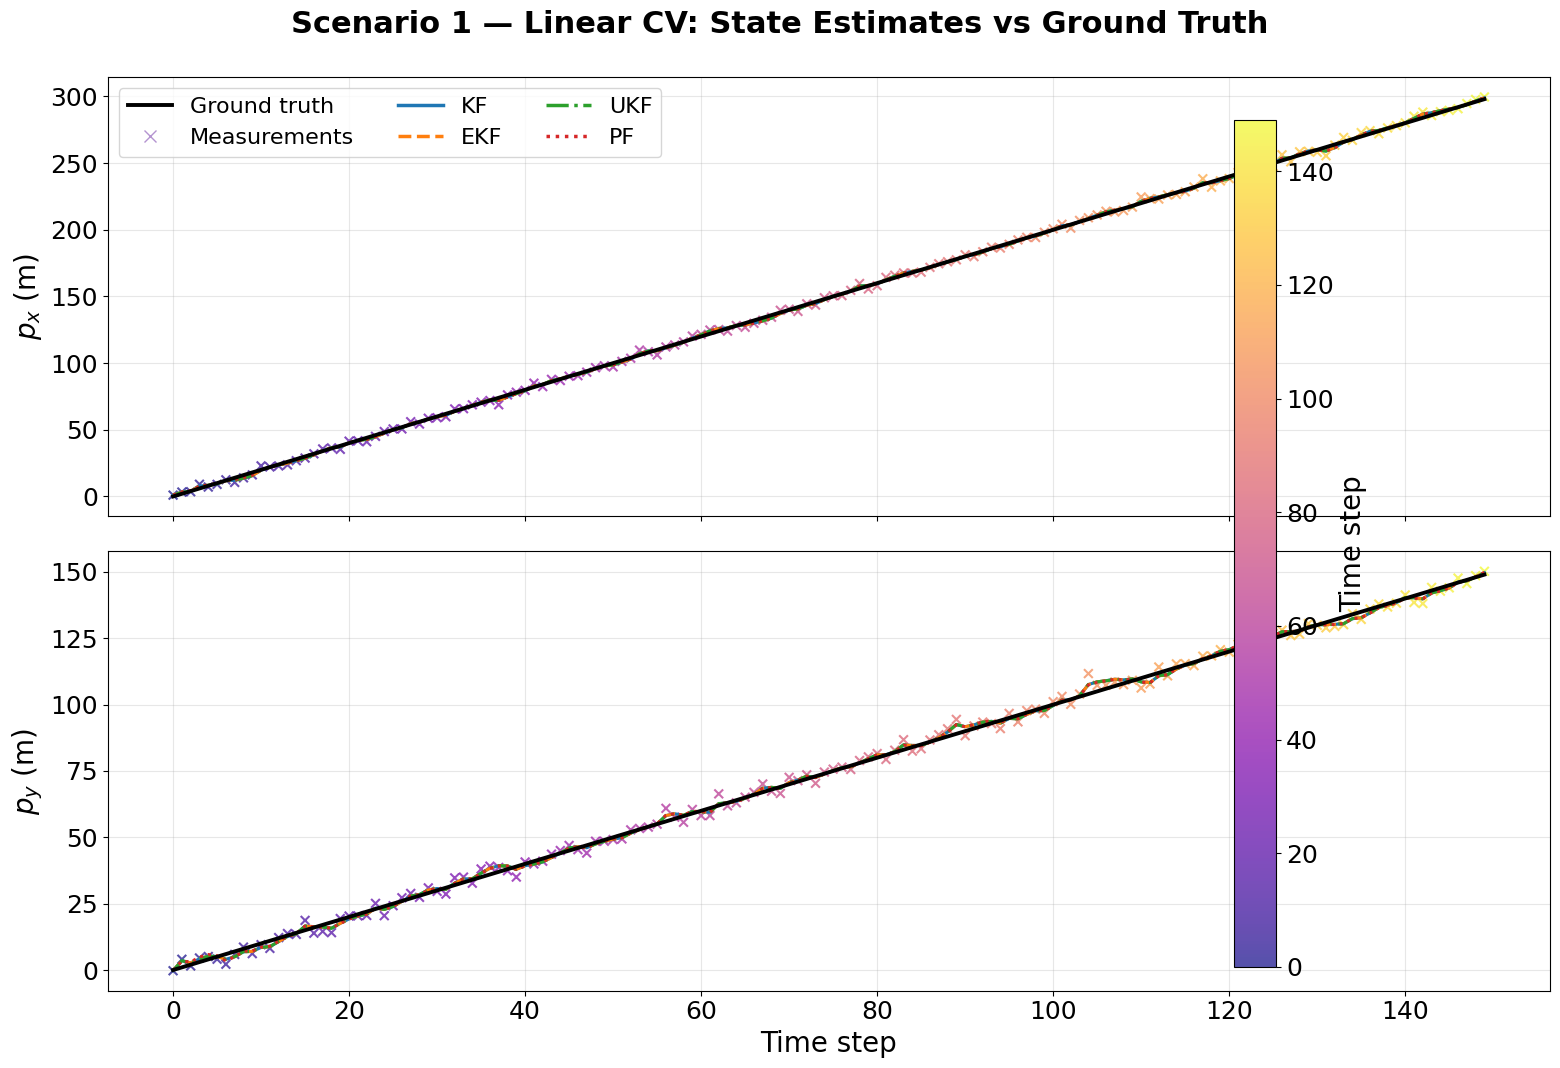

In [9]:
fig, axes = plt.subplots(2,1,figsize=(16,11),sharex=True)

for ax, dim, label in zip(axes,[0,1],['$p_x$ (m)','$p_y$ (m)']):
    ax.plot(t1, true_states_1[:,dim], 'k-', lw=2.8, label='Ground truth', zorder=5)
    sc = plasma_scatter(ax, t1, z1[:,dim], label='Measurements')
    for f in FILTERS:
        ax.plot(t1, est1[f][:,dim], color=COLORS[f], ls=LSTYLE[f], lw=2.2, label=f, zorder=4)
    ax.set_ylabel(label); ax.grid(True,alpha=0.3)
    if dim==0:
        cb=add_colorbar(fig, sc, axes)
        extra=[Line2D([0],[0],color='k',lw=2.8,label='Ground truth'),
               Line2D([0],[0],marker='x',color='C4',ms=9,ls='',lw=1.5,alpha=0.7,label='Measurements')]
        ax.legend(handles=legend_handles(extra), ncol=3)

axes[-1].set_xlabel('Time step')
fig.suptitle('Scenario 1 — Linear CV: State Estimates vs Ground Truth', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/s1_state_estimates.png')
plt.show()

### Figure 1b — 2-D Trajectory (px vs py)

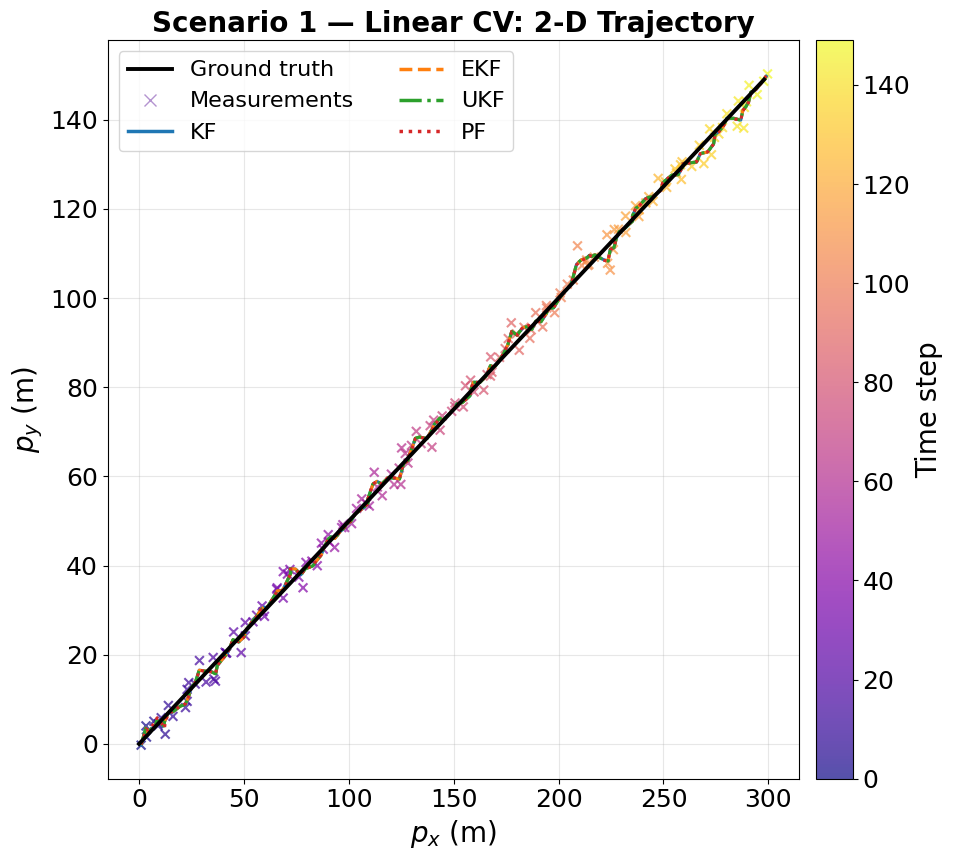

In [10]:
fig, ax = plt.subplots(figsize=(10,9))
ax.plot(true_states_1[:,0], true_states_1[:,1], 'k-', lw=2.8, label='Ground truth', zorder=5)
sc = plasma_scatter_2d(ax, z1[:,0], z1[:,1], t1, label='Measurements')
for f in FILTERS:
    ax.plot(est1[f][:,0], est1[f][:,1],
            color=COLORS[f], ls=LSTYLE[f], lw=2.2, label=f, zorder=4)
cb = fig.colorbar(sc, ax=ax, pad=0.02)
cb.set_label('Time step', fontsize=FS); cb.ax.tick_params(labelsize=FS_TICK)
extra = [Line2D([0],[0],color='k',lw=2.8,label='Ground truth'),
         Line2D([0],[0],marker='x',color='C4',ms=9,ls='',lw=1.5,alpha=0.7,label='Measurements')]
ax.legend(handles=legend_handles(extra), ncol=2)
ax.set_xlabel('$p_x$ (m)'); ax.set_ylabel('$p_y$ (m)')
ax.set_title('Scenario 1 — Linear CV: 2-D Trajectory', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('figures/s1_trajectory.png'); plt.show()


### Figure 2 — RMSE Comparison

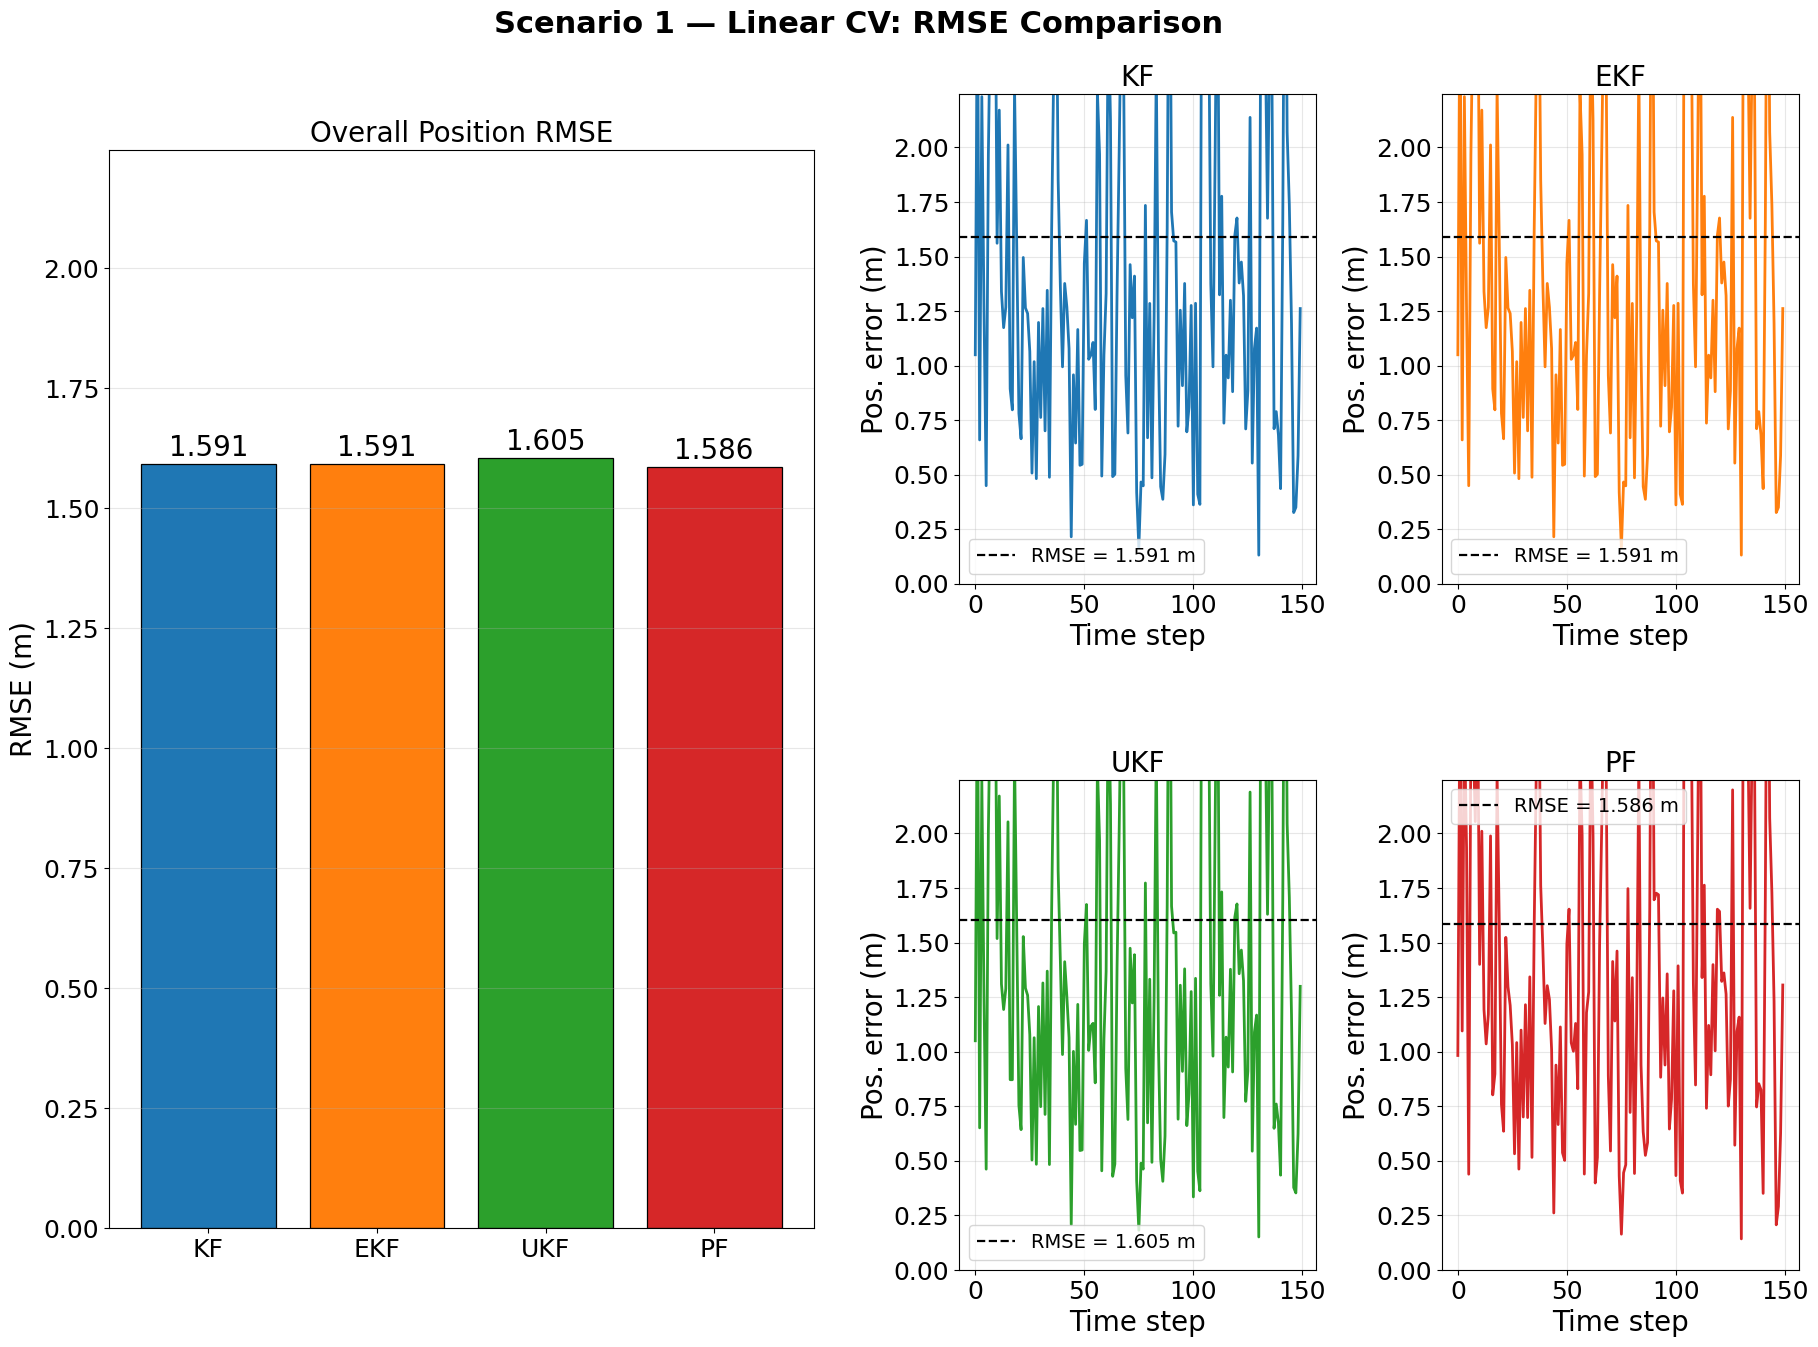

In [11]:
overall1 = {f: np.sqrt(np.mean(np.sum((est1[f][:,:2]-true_states_1[:,:2])**2, axis=1))) for f in FILTERS}

fig = plt.figure(figsize=(20, 14))

# Left column: bar chart (full height)
ax_bar = fig.add_subplot(1, 2, 1)
bars = ax_bar.bar(FILTERS, [overall1[f] for f in FILTERS],
                  color=[COLORS[f] for f in FILTERS], edgecolor='k', lw=0.9)
for bar, f in zip(bars, FILTERS):
    ax_bar.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{overall1[f]:.3f}', ha='center', va='bottom', fontsize=FS)
ax_bar.set_ylabel('RMSE (m)'); ax_bar.set_title('Overall Position RMSE')
ax_bar.grid(True, axis='y', alpha=0.3)
rmse_ylim = max(overall1.values()) * 1.4
ax_bar.set_ylim(0, rmse_ylim)

# Right column: 2×2 per-filter position error
gs_right = fig.add_gridspec(2, 2, left=0.55, right=0.97, top=0.92, bottom=0.08,
                              hspace=0.40, wspace=0.35)
for idx, f in enumerate(FILTERS):
    ax = fig.add_subplot(gs_right[idx//2, idx%2])
    err = pos_err_ts(est1[f], true_states_1)
    rmse_f = np.sqrt(np.mean(err**2))
    ax.plot(t1, err, color=COLORS[f], lw=2.0)
    ax.axhline(rmse_f, color='k', ls='--', lw=1.6, label=f'RMSE = {rmse_f:.3f} m')
    ax.set_title(f); ax.set_xlabel('Time step'); ax.set_ylabel('Pos. error (m)')
    ax.legend(fontsize=FS_LEG-2); ax.grid(True, alpha=0.3)
    ax.set_ylim(0, rmse_ylim)

fig.suptitle('Scenario 1 — Linear CV: RMSE Comparison', fontweight='bold')
plt.savefig('figures/s1_rmse.png'); plt.show()


### Figure 3 — NEES with χ² Bounds

<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:11: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:11: SyntaxWarning: invalid escape sequence '\c'
/var/folders/2v/9n_l6bfd7y9f_1gmwjt3st900000gn/T/ipykernel_93971/2680946006.py:6: SyntaxWarning: invalid escape sequence '\c'
  ax.set_title(f'{f}  —  {pct:.0f}% within 95% $\chi^2_4$ bounds')
/var/folders/2v/9n_l6bfd7y9f_1gmwjt3st900000gn/T/ipykernel_93971/2680946006.py:11: SyntaxWarning: invalid escape sequence '\c'
  fig.suptitle('Scenario 1 — Linear CV: NEES with $\chi^2_4$ Bounds', fontweight='bold')


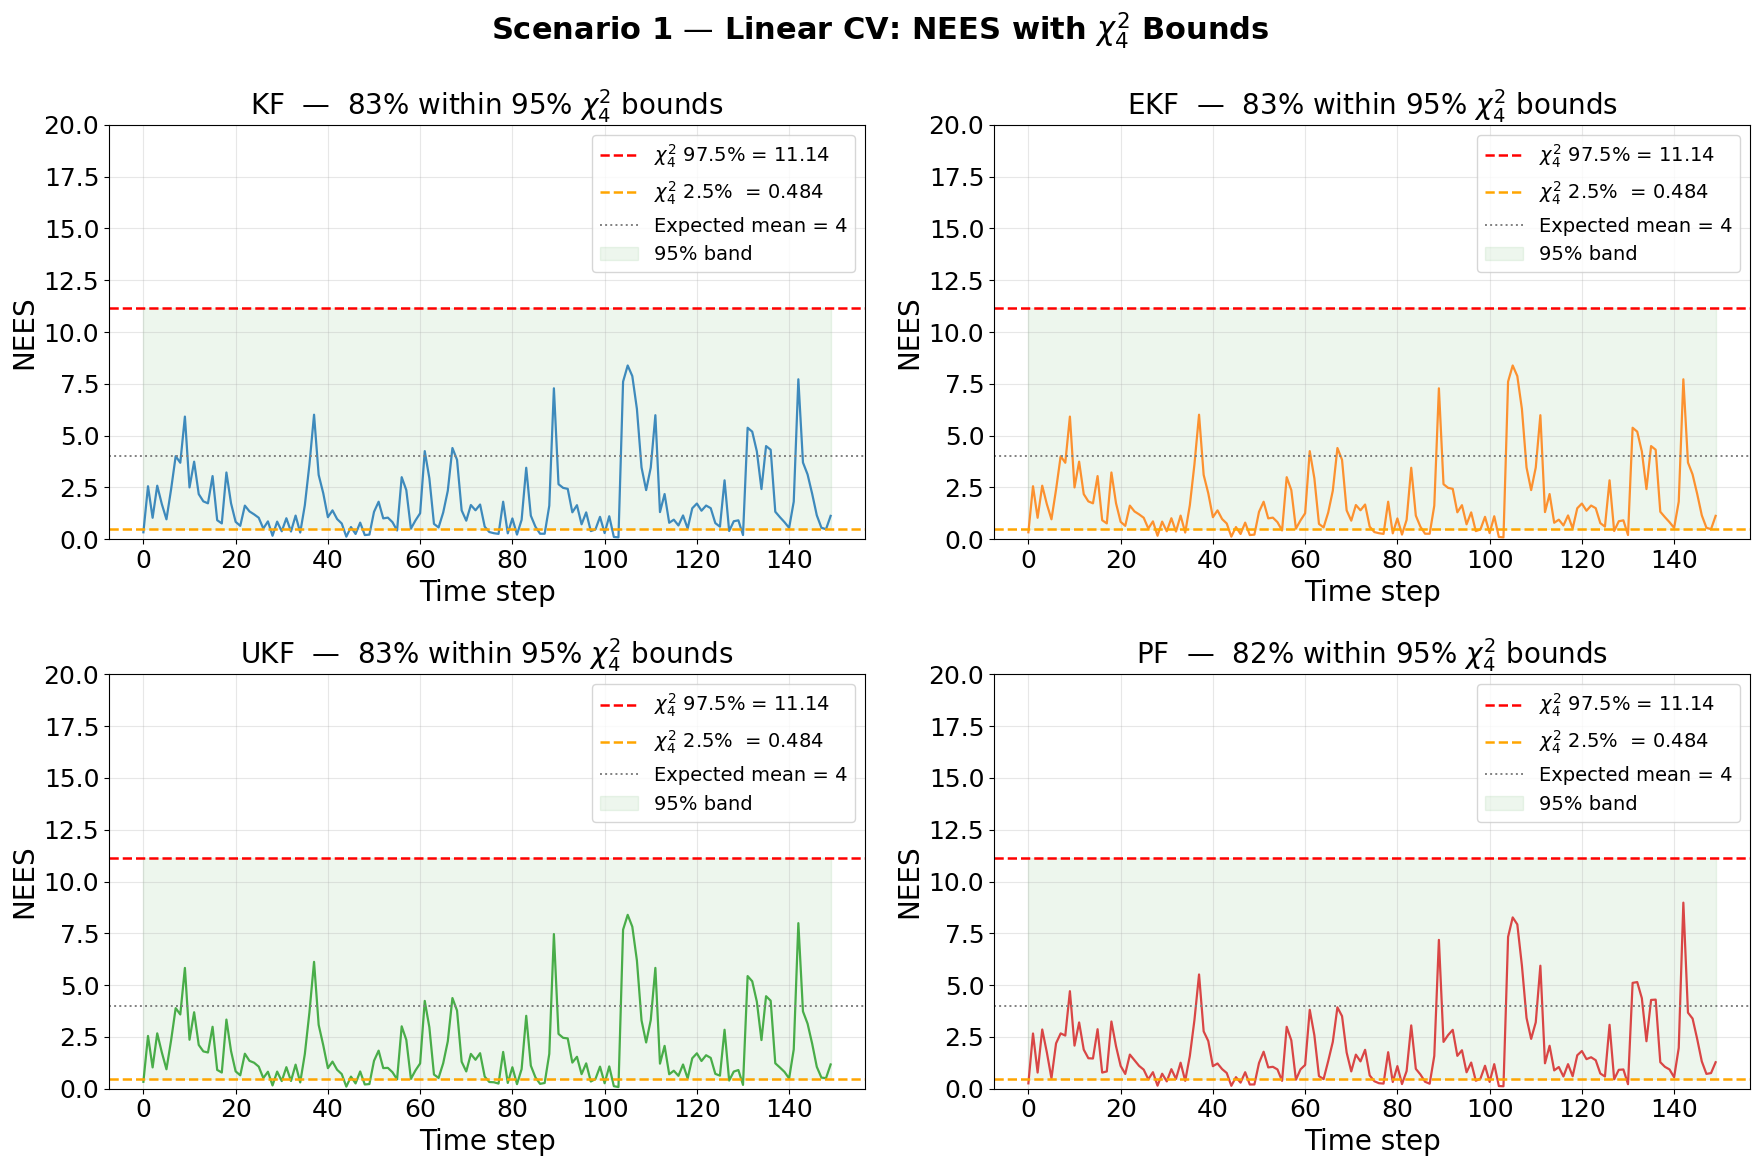

In [12]:
fig, axes = plt.subplots(2,2,figsize=(18,12))
for ax,f in zip(axes.flatten(),FILTERS):
    ne=nees1[f]; pct=np.mean((ne>=chi2_lo4)&(ne<=chi2_hi4))*100
    ax.plot(t1, ne, color=COLORS[f], lw=1.6, alpha=0.85)
    _add_chi2_bands(ax,t1,chi2_lo4,chi2_hi4,4)
    ax.set_title(f'{f}  —  {pct:.0f}% within 95% $\chi^2_4$ bounds')
    ax.set_xlabel('Time step'); ax.set_ylabel('NEES')
    ax.set_ylim(0,max(20,float(np.percentile(ne,97))))
    ax.legend(fontsize=FS_LEG-2); ax.grid(True,alpha=0.3)

fig.suptitle('Scenario 1 — Linear CV: NEES with $\chi^2_4$ Bounds', fontweight='bold')
plt.tight_layout(); plt.savefig('figures/s1_nees.png'); plt.show()


---
## Scenario 2 — Nonlinear: Range-Bearing Measurements, CTRV Trajectory

**Measurement model:** `z = [r, θ] = [‖p‖, arctan2(py, px)]` — nonlinear.
**Trajectory:** constant turn-rate (ω = 0.05 rad/s), producing a full arc.

| Filter | Measurement handling |
|--------|---------------------|
| KF | converts z → pseudo-Cartesian `[r·cos θ, r·sin θ]` (biased) |
| EKF | analytical Jacobian H at each step |
| UKF | sigma points through h(x) — no Jacobian |
| PF | exact Gaussian likelihood in [r, θ] space |

In [13]:
DT2, N2        = 1.0, 120
OMEGA2         = 0.05          # rad/s
SIGMA_A2_2     = 0.1
SIGMA_R2       = 15.0
SIGMA_TH2      = np.deg2rad(2.0)
R2             = np.diag([SIGMA_R2**2, SIGMA_TH2**2])
F2, Q2         = make_F(DT2), make_Q(SIGMA_A2_2, DT2)
Wm2,Wc2,lam2   = ukf_weights(4)

x0_true_2 = np.array([500.,0.,0.,10.])
x0_2      = np.array([500.,0.5,0.5,9.5])
P0_2      = np.diag([SIGMA_R2**2, SIGMA_R2**2, 5.**2, 5.**2])

def simulate_ctrv_4d(x0,N,dt,omega):
    states=np.zeros((N,4)); states[0]=x0
    for k in range(1,N):
        px,py,vx,vy=states[k-1]; ct=np.cos(omega*dt); st=np.sin(omega*dt)
        states[k]=[px+vx*dt, py+vy*dt, vx*ct-vy*st, vx*st+vy*ct]
    return states

def simulate_rb(states, sr, sth, rng=None):
    rng=rng or np.random; N=len(states); z=np.zeros((N,2))
    z[:,0]=np.hypot(states[:,0],states[:,1])+rng.randn(N)*sr
    z[:,1]=np.arctan2(states[:,1],states[:,0])+rng.randn(N)*sth
    return z

np.random.seed(99)
true_states_2 = simulate_ctrv_4d(x0_true_2,N2,DT2,OMEGA2)
z2            = simulate_rb(true_states_2,SIGMA_R2,SIGMA_TH2)
t2            = np.arange(N2)

# KF: convert range-bearing → pseudo-Cartesian; compute R via Jacobian at each step
z2_cart = np.column_stack([z2[:,0]*np.cos(z2[:,1]), z2[:,0]*np.sin(z2[:,1])])

def rb_to_cart_R(x_pred, R_rb):
    """Propagate range-bearing noise covariance to Cartesian via Jacobian at x_pred."""
    r = max(np.hypot(x_pred[0], x_pred[1]), 1e-6)
    ct, st = x_pred[0]/r, x_pred[1]/r
    J = np.array([[ct, -r*st], [st, r*ct]])
    return J @ R_rb @ J.T

# ── run filters ───────────────────────────────────────────────────────────────
est2,cov2,nis2 = {},{},{}

x,P=x0_2.copy(),P0_2.copy(); e,c,n=[],[],[]
for k in range(N2):
    x,P=kf_predict(x,P,F2,Q2)
    R2_cart_k = rb_to_cart_R(x, R2)
    x,P,ni=kf_update(x,P,z2_cart[k],H_CART,R2_cart_k)
    e.append(x.copy()); c.append(P.copy()); n.append(ni)
est2['KF'],cov2['KF'],nis2['KF'] = np.array(e),c,np.array(n)

x,P=x0_2.copy(),P0_2.copy(); e,c,n=[],[],[]
for k in range(N2):
    x,P=ekf_predict_ctrv(x,P,Q2,DT2,OMEGA2); x,P,ni=ekf_update_rb(x,P,z2[k],R2)
    e.append(x.copy()); c.append(P.copy()); n.append(ni)
est2['EKF'],cov2['EKF'],nis2['EKF'] = np.array(e),c,np.array(n)

ctrv_f_s2 = lambda s: ctrv_f(s, DT2, OMEGA2)
x,P=x0_2.copy(),P0_2.copy(); e,c,n=[],[],[]
for k in range(N2):
    x,P,sf=ukf_predict_nl(x,P,Q2,ctrv_f_s2,Wm2,Wc2,lam2); x,P,ni=ukf_update_rb(x,P,sf,z2[k],R2,Wm2,Wc2)
    e.append(x.copy()); c.append(P.copy()); n.append(ni)
est2['UKF'],cov2['UKF'],nis2['UKF'] = np.array(e),c,np.array(n)

np.random.seed(299)
particles,weights=pf_init(N_PF,x0_2,np.array([SIGMA_R2,SIGMA_R2,5.,5.]))
e,c,n=[],[],[]
for k in range(N2):
    particles=pf_predict_ctrv(particles,DT2,OMEGA2,np.sqrt(SIGMA_A2_2))
    weights=pf_update_rb(particles,weights,z2[k],R2)
    ni=pf_nis_rb(particles,weights,z2[k],R2)
    particles,weights=pf_resample(particles,weights)
    e.append(pf_estimate(particles,weights)); c.append(pf_cov(particles,weights)); n.append(ni)
est2['PF'],cov2['PF'],nis2['PF'] = np.array(e),c,np.array(n)

nees2 = {f: nees_ts(est2[f],cov2[f],true_states_2) for f in FILTERS}
print("Scenario 2 filters complete.")

Scenario 2 filters complete.


### Figure 4 — State Estimates (px and py over time)

/var/folders/2v/9n_l6bfd7y9f_1gmwjt3st900000gn/T/ipykernel_93971/2515182622.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.savefig('figures/s2_state_estimates.png'); plt.show()


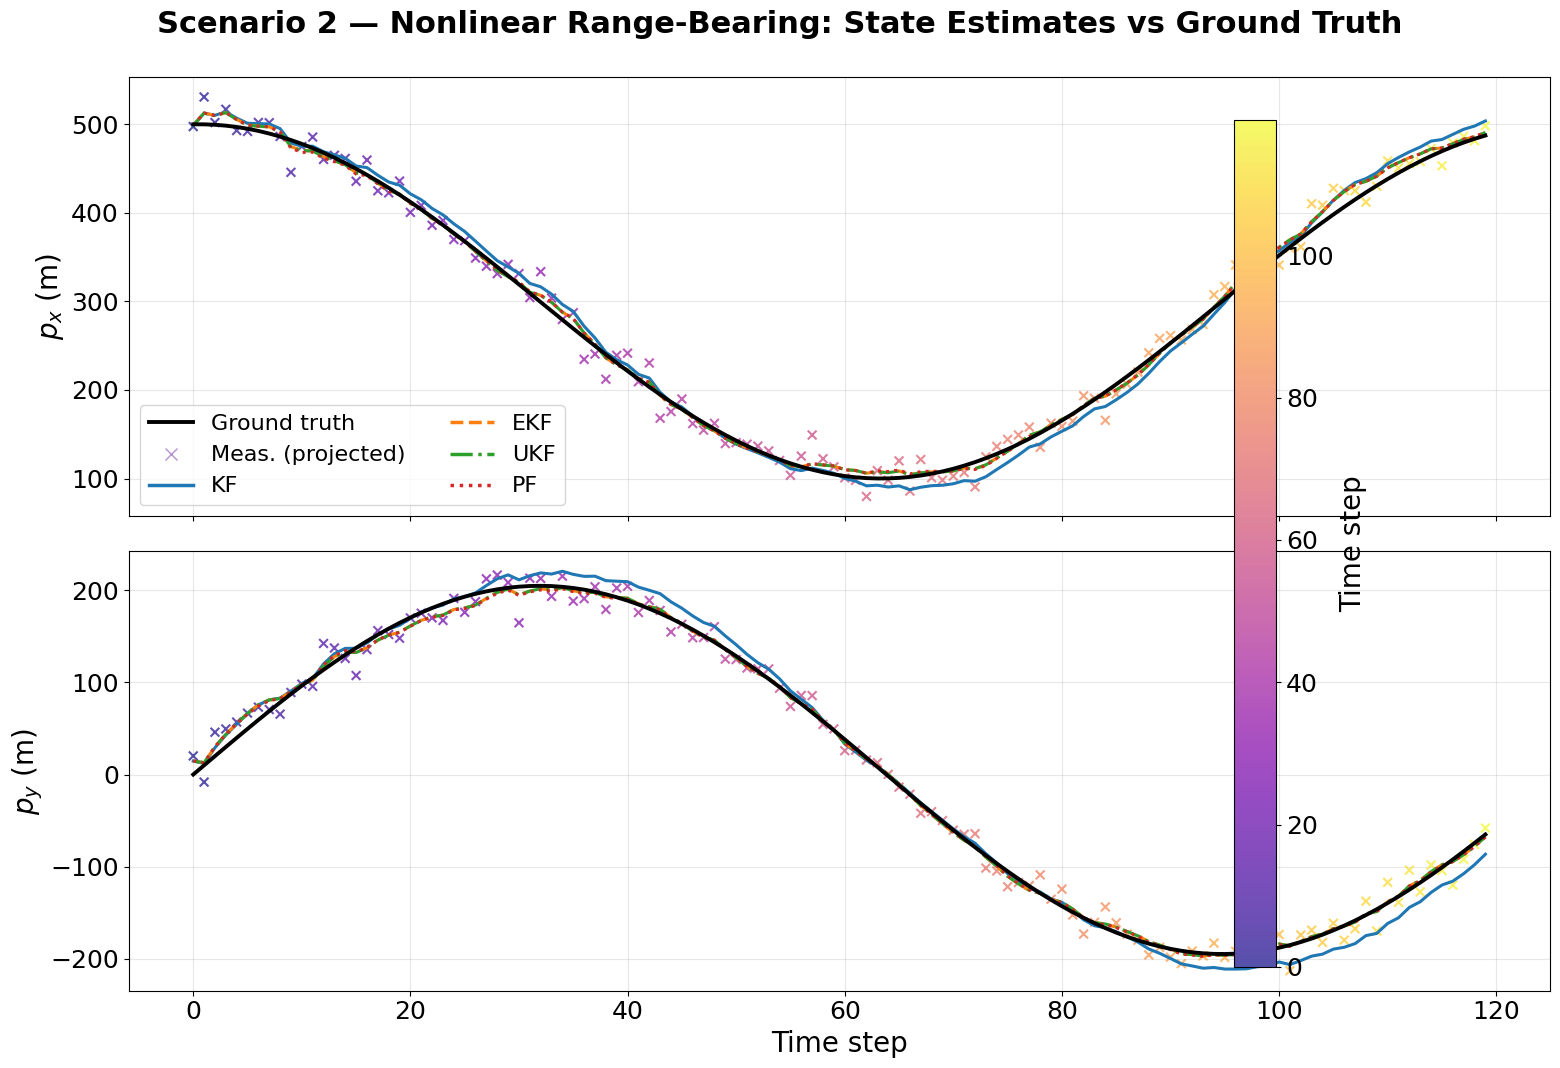

In [14]:
# Project range-bearing measurements back to Cartesian for plotting
meas2_x = z2[:,0]*np.cos(z2[:,1])
meas2_y = z2[:,0]*np.sin(z2[:,1])

fig, axes = plt.subplots(2,1,figsize=(16,11),sharex=True)

for ax, dim, meas_vals, label in zip(
        axes,[0,1],[meas2_x, meas2_y],['$p_x$ (m)','$p_y$ (m)']):
    ax.plot(t2, true_states_2[:,dim], 'k-', lw=2.8, label='Ground truth', zorder=5)
    sc = plasma_scatter(ax, t2, meas_vals, label='Measurements (projected)')
    for f in FILTERS:
        rmse_f=np.sqrt(np.mean((est2[f][:,dim]-true_states_2[:,dim])**2))
        ax.plot(t2, est2[f][:,dim], color=COLORS[f], ls=LSTYLE[f], lw=2.2,
                label=f'{f} (RMSE={rmse_f:.1f} m)', zorder=4)
    ax.set_ylabel(label); ax.grid(True,alpha=0.3)
    if dim==0:
        cb=add_colorbar(fig, sc, axes)
        extra=[Line2D([0],[0],color='k',lw=2.8,label='Ground truth'),
               Line2D([0],[0],marker='x',color='C4',ms=9,ls='',lw=1.5,alpha=0.7,
                      label='Meas. (projected)')]
        ax.legend(handles=legend_handles(extra), ncol=2)

axes[-1].set_xlabel('Time step')
fig.suptitle('Scenario 2 — Nonlinear Range-Bearing: State Estimates vs Ground Truth',
             fontweight='bold')
plt.tight_layout(); plt.savefig('figures/s2_state_estimates.png'); plt.show()

### Figure 4b — 2-D Trajectory (px vs py)

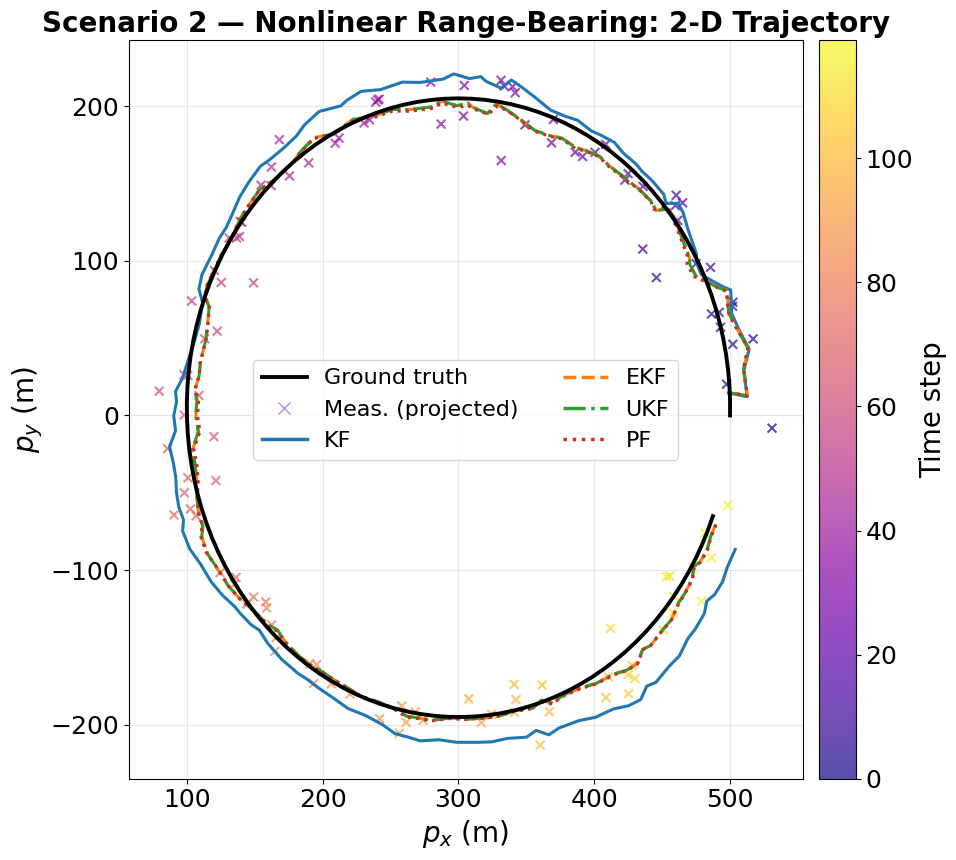

In [15]:
fig, ax = plt.subplots(figsize=(10,9))
ax.plot(true_states_2[:,0], true_states_2[:,1], 'k-', lw=2.8, label='Ground truth', zorder=5)
sc = plasma_scatter_2d(ax, meas2_x, meas2_y, t2, label='Meas. (projected)')
for f in FILTERS:
    ax.plot(est2[f][:,0], est2[f][:,1],
            color=COLORS[f], ls=LSTYLE[f], lw=2.2, label=f, zorder=4)
cb = fig.colorbar(sc, ax=ax, pad=0.02)
cb.set_label('Time step', fontsize=FS); cb.ax.tick_params(labelsize=FS_TICK)
extra = [Line2D([0],[0],color='k',lw=2.8,label='Ground truth'),
         Line2D([0],[0],marker='x',color='C4',ms=9,ls='',lw=1.5,alpha=0.7,
                label='Meas. (projected)')]
ax.legend(handles=legend_handles(extra), ncol=2)
ax.set_xlabel('$p_x$ (m)'); ax.set_ylabel('$p_y$ (m)')
ax.set_title('Scenario 2 — Nonlinear Range-Bearing: 2-D Trajectory', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('figures/s2_trajectory.png'); plt.show()


### Figure 5 — NEES over Time (key divergence plot)

<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
/var/folders/2v/9n_l6bfd7y9f_1gmwjt3st900000gn/T/ipykernel_93971/423438210.py:6: SyntaxWarning: invalid escape sequence '\c'
  label=f'{f} ({pct:.0f}% in $\chi^2_4$ bounds)')


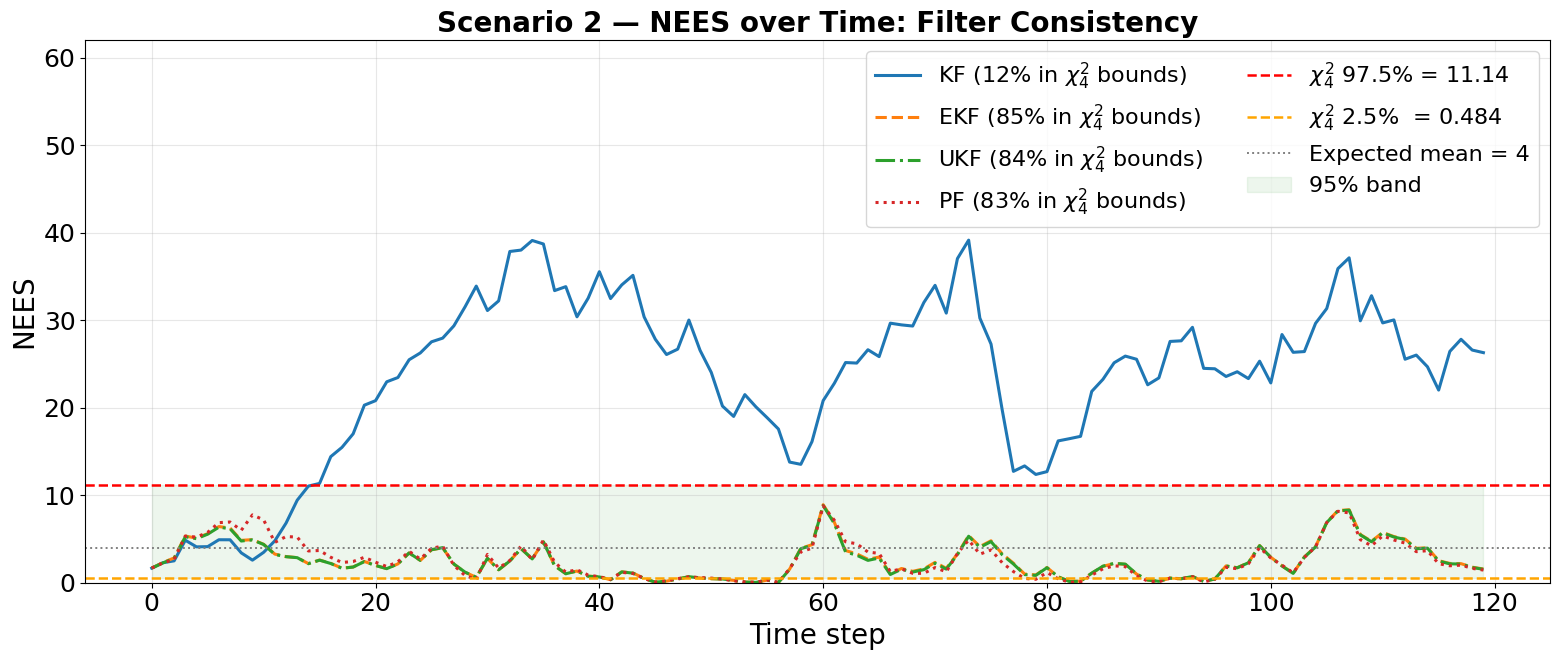

In [16]:
fig, ax = plt.subplots(figsize=(16,7))
for f in FILTERS:
    vals=np.clip(nees2[f],0,60)
    pct=np.mean((nees2[f]>=chi2_lo4)&(nees2[f]<=chi2_hi4))*100
    ax.plot(t2, vals, color=COLORS[f], ls=LSTYLE[f], lw=2.2,
            label=f'{f} ({pct:.0f}% in $\chi^2_4$ bounds)')
_add_chi2_bands(ax,t2,chi2_lo4,chi2_hi4,4)
ax.set_xlabel('Time step'); ax.set_ylabel('NEES')
ax.set_ylim(0,62)
ax.set_title('Scenario 2 — NEES over Time: Filter Consistency', fontweight='bold')
ax.legend(ncol=2); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig('figures/s2_nees.png'); plt.show()


### Figure 6 — Monte Carlo RMSE (100 runs)

Running Monte Carlo (100 runs) — this may take ~60 s …


Monte Carlo complete.


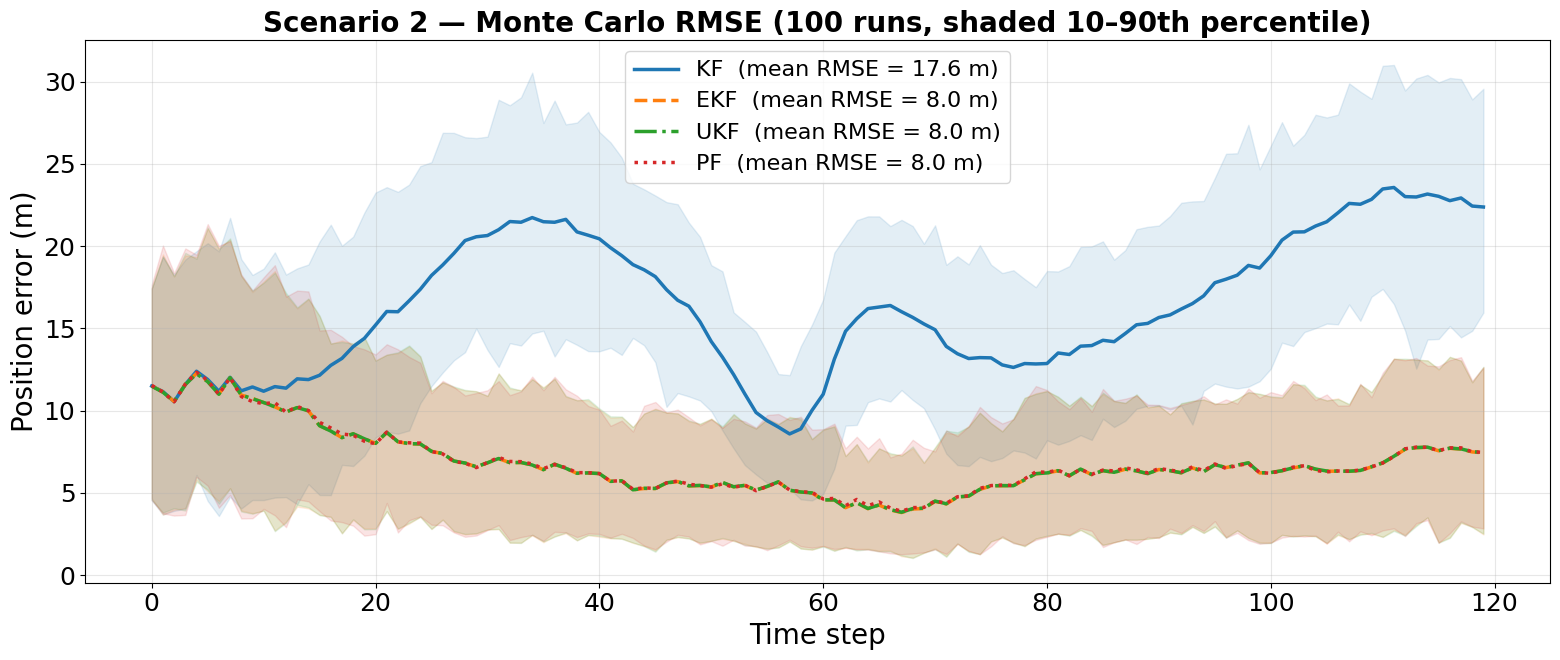

In [17]:
print("Running Monte Carlo (100 runs) — this may take ~60 s …")
N_MC=100; mc_err={f:np.zeros((N_MC,N2)) for f in FILTERS}
sa2=np.sqrt(SIGMA_A2_2)

for mc in range(N_MC):
    rng_mc=np.random.RandomState(2000+mc)
    zm=simulate_rb(true_states_2,SIGMA_R2,SIGMA_TH2,rng=rng_mc)
    x,P=x0_2.copy(),P0_2.copy()
    for k in range(N2):
        x,P=kf_predict(x,P,F2,Q2)
        R2_cart_k=rb_to_cart_R(x,R2)
        zc_k=np.array([zm[k,0]*np.cos(zm[k,1]),zm[k,0]*np.sin(zm[k,1])])
        x,P,_=kf_update(x,P,zc_k,H_CART,R2_cart_k)
        mc_err['KF'][mc,k]=np.hypot(x[0]-true_states_2[k,0],x[1]-true_states_2[k,1])

    x,P=x0_2.copy(),P0_2.copy()
    for k in range(N2):
        x,P=ekf_predict_ctrv(x,P,Q2,DT2,OMEGA2); x,P,_=ekf_update_rb(x,P,zm[k],R2)
        mc_err['EKF'][mc,k]=np.hypot(x[0]-true_states_2[k,0],x[1]-true_states_2[k,1])

    x,P=x0_2.copy(),P0_2.copy()
    for k in range(N2):
        x,P,sf=ukf_predict_nl(x,P,Q2,ctrv_f_s2,Wm2,Wc2,lam2); x,P,_=ukf_update_rb(x,P,sf,zm[k],R2,Wm2,Wc2)
        mc_err['UKF'][mc,k]=np.hypot(x[0]-true_states_2[k,0],x[1]-true_states_2[k,1])

    np.random.seed(3000+mc)
    p,w=pf_init(N_PF,x0_2,np.array([SIGMA_R2,SIGMA_R2,5.,5.]))
    for k in range(N2):
        p=pf_predict_ctrv(p,DT2,OMEGA2,sa2); w=pf_update_rb(p,w,zm[k],R2)
        p,w=pf_resample(p,w); est_k=pf_estimate(p,w)
        mc_err['PF'][mc,k]=np.hypot(est_k[0]-true_states_2[k,0],est_k[1]-true_states_2[k,1])

print("Monte Carlo complete.")

fig, ax = plt.subplots(figsize=(16,7))
for f in FILTERS:
    mn=mc_err[f].mean(axis=0); lo=np.percentile(mc_err[f],10,axis=0)
    hi=np.percentile(mc_err[f],90,axis=0)
    rmse_f=np.sqrt(np.mean(mc_err[f]**2))
    ax.plot(t2, mn, color=COLORS[f], ls=LSTYLE[f], lw=2.5,
            label=f'{f}  (mean RMSE = {rmse_f:.1f} m)')
    ax.fill_between(t2, lo, hi, color=COLORS[f], alpha=0.12)
ax.set_xlabel('Time step'); ax.set_ylabel('Position error (m)')
ax.set_title(f'Scenario 2 — Monte Carlo RMSE ({N_MC} runs, shaded 10–90th percentile)',
             fontweight='bold')
ax.legend(); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig('figures/s2_mc_rmse.png'); plt.show()

---
## Scenario 3 — Non-Gaussian Noise: Student-t (ν = 3)

Same linear CV system as Scenario 1, but measurement noise drawn from a
**Student-t distribution with ν = 3** (heavy tails, frequent large outliers).

- **KF / EKF / UKF** assume Gaussian R → pulled by outliers, consistency breaks
- **PF** uses exact Student-t likelihood → outlier-robust

In [18]:
DT3, N3      = 1.0, 150
NU           = 3
SIGMA_POS3   = 2.0
R3_gauss     = np.diag([SIGMA_POS3**2]*2)
F3, Q3       = make_F(DT3), make_Q(SIGMA_A2_1, DT3)
Wm3,Wc3,lam3 = ukf_weights(4)

x0_true_3 = np.array([0.,0.,2.,1.])
x0_3      = np.array([0.5,0.5,1.5,0.8])
P0_3      = np.diag([10.**2,10.**2,5.**2,5.**2])

np.random.seed(77)
true_states_3=np.zeros((N3,4)); true_states_3[0]=x0_true_3
for k in range(1,N3): true_states_3[k]=F3@true_states_3[k-1]
t_noise = t_dist.rvs(df=NU, scale=SIGMA_POS3, size=(N3,2))
z3      = true_states_3[:,:2] + t_noise
t3      = np.arange(N3)
outlier_thresh  = t_dist.ppf(0.975,df=NU)*SIGMA_POS3
outlier_steps   = np.where(np.any(np.abs(t_noise)>outlier_thresh,axis=1))[0]

# ── run filters ───────────────────────────────────────────────────────────────
est3,cov3 = {},{}

x,P=x0_3.copy(),P0_3.copy(); e,c,n=[],[],[]
for k in range(N3):
    x,P=kf_predict(x,P,F3,Q3); x,P,ni=kf_update(x,P,z3[k],H_CART,R3_gauss)
    e.append(x.copy()); c.append(P.copy()); n.append(ni)
est3['KF'],cov3['KF'],nis3_kf = np.array(e),c,np.array(n)

x,P=x0_3.copy(),P0_3.copy(); e,c,n=[],[],[]
for k in range(N3):
    x,P=ekf_predict(x,P,F3,Q3); x,P,ni=ekf_update_cartesian(x,P,z3[k],H_CART,R3_gauss)
    e.append(x.copy()); c.append(P.copy()); n.append(ni)
est3['EKF'],cov3['EKF'],nis3_ekf = np.array(e),c,np.array(n)

x,P=x0_3.copy(),P0_3.copy(); e,c,n=[],[],[]
for k in range(N3):
    x,P,sf=ukf_predict(x,P,Q3,F3,Wm3,Wc3,lam3)
    x,P,ni=ukf_update_cartesian(x,P,sf,z3[k],H_CART,R3_gauss,Wm3,Wc3)
    e.append(x.copy()); c.append(P.copy()); n.append(ni)
est3['UKF'],cov3['UKF'],nis3_ukf = np.array(e),c,np.array(n)

np.random.seed(377)
particles,weights=pf_init(N_PF,x0_3,np.array([10.,10.,5.,5.]))
e,c,n=[],[],[]
for k in range(N3):
    particles=pf_predict_cv(particles,DT3,np.sqrt(SIGMA_A2_1))
    weights=pf_update_student_t(particles,weights,z3[k],R3_gauss,nu=NU)
    particles,weights=pf_resample(particles,weights)
    e.append(pf_estimate(particles,weights)); c.append(pf_cov(particles,weights))
    n.append(pf_nis_cartesian(particles,weights,z3[k],R3_gauss))
est3['PF'],cov3['PF'],nis3_pf = np.array(e),c,np.array(n)

nees3    = {f: nees_ts(est3[f],cov3[f],true_states_3) for f in FILTERS}
nis3     = {'KF':nis3_kf,'EKF':nis3_ekf,'UKF':nis3_ukf,'PF':nis3_pf}
overall3 = {f: np.sqrt(np.mean(np.sum((est3[f][:,:2]-true_states_3[:,:2])**2, axis=1))) for f in FILTERS}
print("Scenario 3 filters complete.")

Scenario 3 filters complete.


### Figure 7 — RMSE Comparison

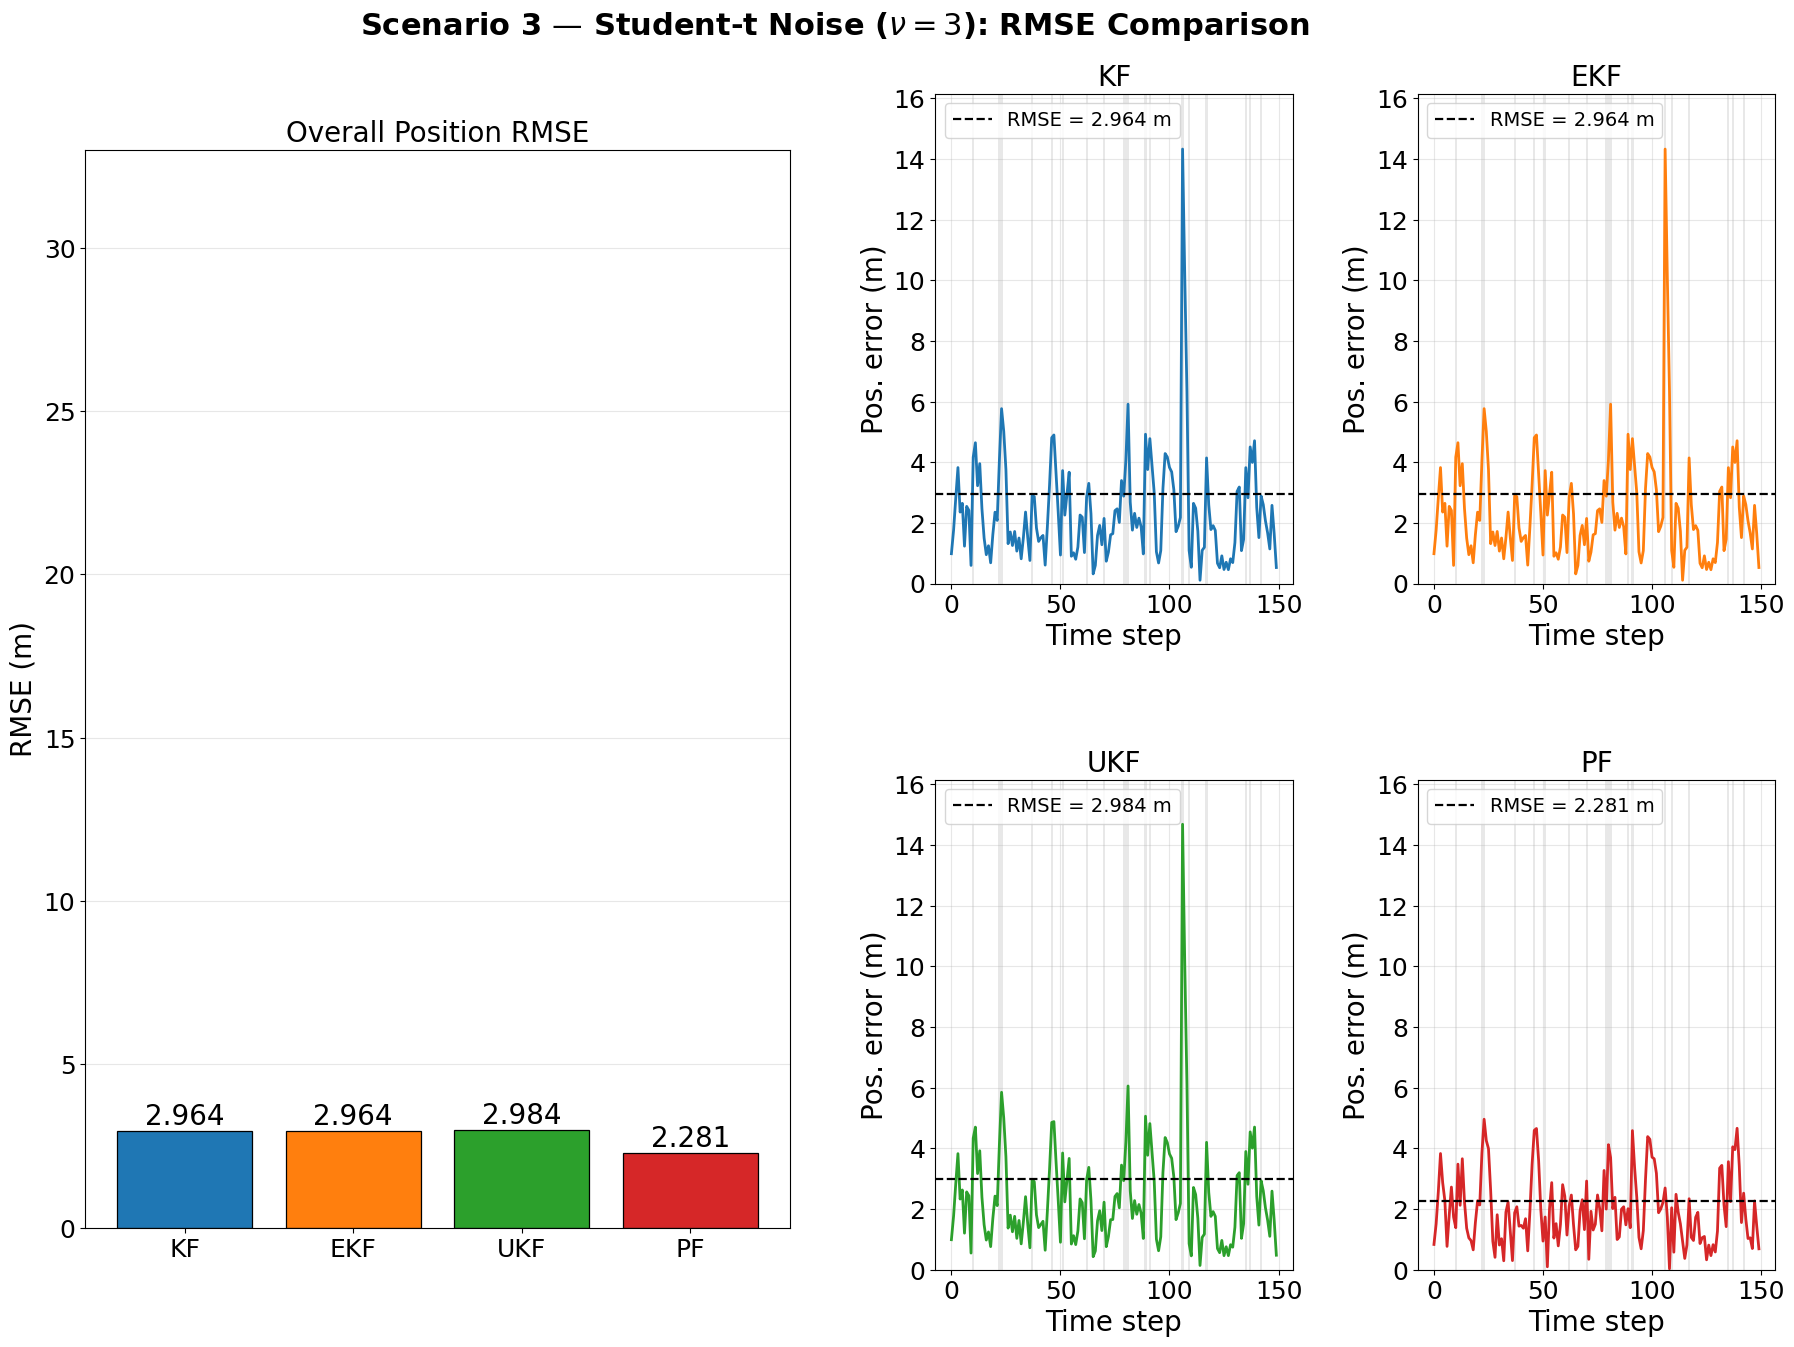

In [19]:
overall3 = {f: np.sqrt(np.mean(np.sum((est3[f][:,:2]-true_states_3[:,:2])**2, axis=1))) for f in FILTERS}

fig = plt.figure(figsize=(20, 14))

# Left column: bar chart
ax_bar = fig.add_subplot(1, 2, 1)
bars = ax_bar.bar(FILTERS, [overall3[f] for f in FILTERS],
                  color=[COLORS[f] for f in FILTERS], edgecolor='k', lw=0.9)
for bar, f in zip(bars, FILTERS):
    ax_bar.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{overall3[f]:.3f}', ha='center', va='bottom', fontsize=FS)
ax_bar.set_ylabel('RMSE (m)'); ax_bar.set_title('Overall Position RMSE')
ax_bar.grid(True, axis='y', alpha=0.3)
rmse_ylim = RMSE_S3S4_YLIM
ax_bar.set_ylim(0, rmse_ylim)

# Right: 2×2 per-filter position error with outlier shading
panel_ylim = max(pos_err_ts(est3[f], true_states_3).max() for f in FILTERS) * 1.1
gs_right = fig.add_gridspec(2, 2, left=0.55, right=0.97, top=0.92, bottom=0.08,
                              hspace=0.40, wspace=0.35)
for idx, f in enumerate(FILTERS):
    ax = fig.add_subplot(gs_right[idx//2, idx%2])
    err = pos_err_ts(est3[f], true_states_3)
    rmse_f = np.sqrt(np.mean(err**2))
    for k in outlier_steps:
        ax.axvspan(k-0.5, k+0.5, color='grey', alpha=0.18, lw=0)
    ax.plot(t3, err, color=COLORS[f], lw=2.0)
    ax.axhline(rmse_f, color='k', ls='--', lw=1.6, label=f'RMSE = {rmse_f:.3f} m')
    ax.set_title(f); ax.set_xlabel('Time step'); ax.set_ylabel('Pos. error (m)')
    ax.legend(fontsize=FS_LEG-2); ax.grid(True, alpha=0.3)
    ax.set_ylim(0, panel_ylim)

fig.suptitle(f'Scenario 3 — Student-t Noise ($\\nu={NU}$): RMSE Comparison',
             fontweight='bold')
plt.savefig('figures/s3_rmse.png'); plt.show()


### Figure 8 — NEES Consistency Breakdown

<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
/var/folders/2v/9n_l6bfd7y9f_1gmwjt3st900000gn/T/ipykernel_93971/2274589319.py:6: SyntaxWarning: invalid escape sequence '\c'
  label=f'{f} ({pct:.0f}% in $\chi^2_4$ bounds)')


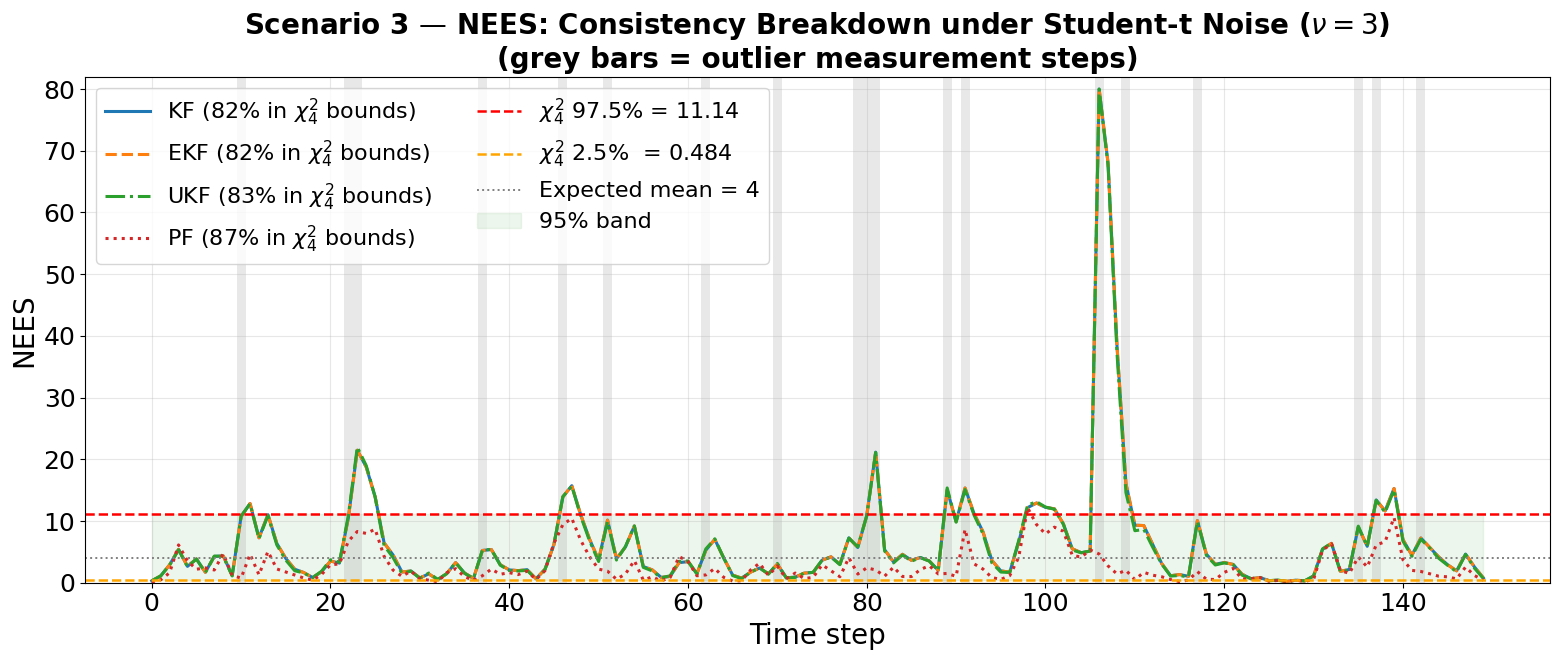

In [20]:
fig, ax = plt.subplots(figsize=(16,7))
for f in FILTERS:
    vals=np.clip(nees3[f],0,80)
    pct=np.mean((nees3[f]>=chi2_lo4)&(nees3[f]<=chi2_hi4))*100
    ax.plot(t3, vals, color=COLORS[f], ls=LSTYLE[f], lw=2.2,
            label=f'{f} ({pct:.0f}% in $\chi^2_4$ bounds)')
_add_chi2_bands(ax,t3,chi2_lo4,chi2_hi4,4)
for k in outlier_steps:
    ax.axvspan(k-0.5,k+0.5,color='grey',alpha=0.18,lw=0)
ax.set_xlabel('Time step'); ax.set_ylabel('NEES')
ax.set_ylim(0,82)
ax.set_title(
    f'Scenario 3 — NEES: Consistency Breakdown under Student-t Noise ($\\nu={NU}$)\n'
    '(grey bars = outlier measurement steps)', fontweight='bold')
ax.legend(ncol=2); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig('figures/s3_nees.png'); plt.show()


---
## Scenario 4 — Nonlinear + Non-Gaussian: CTRV Trajectory, Student-t Noise

**The hardest scenario.** Same CTRV trajectory and range-bearing measurements as Scenario 2,
but measurement noise is Student-t (ν = 3) instead of Gaussian — combining nonlinear dynamics,
a nonlinear measurement model, and heavy-tailed outliers.
Only the PF can exploit the correct model on all three fronts.

In [21]:
DT4, N4      = 1.0, 120
OMEGA4       = 0.05
NU4          = 3
SIGMA_A2_4   = 0.1
SIGMA_R4     = 15.0
SIGMA_TH4    = np.deg2rad(2.0)
R4           = np.diag([SIGMA_R4**2, SIGMA_TH4**2])
F4, Q4       = make_F(DT4), make_Q(SIGMA_A2_4, DT4)
Wm4,Wc4,lam4 = ukf_weights(4)
ctrv_f_s4    = lambda s: ctrv_f(s, DT4, OMEGA4)

x0_true_4 = np.array([500.,0.,0.,10.])
x0_4      = np.array([500.,0.5,0.5,9.5])
P0_4      = np.diag([SIGMA_R4**2, SIGMA_R4**2, 5.**2, 5.**2])

np.random.seed(44)
true_states_4 = simulate_ctrv_4d(x0_true_4, N4, DT4, OMEGA4)
r4_true  = np.hypot(true_states_4[:,0], true_states_4[:,1])
th4_true = np.arctan2(true_states_4[:,1], true_states_4[:,0])
t_noise_r  = t_dist.rvs(df=NU4, scale=SIGMA_R4,  size=N4)
t_noise_th = t_dist.rvs(df=NU4, scale=SIGMA_TH4, size=N4)
z4 = np.column_stack([r4_true + t_noise_r, th4_true + t_noise_th])
t4 = np.arange(N4)

outlier_thresh_r  = t_dist.ppf(0.975, df=NU4) * SIGMA_R4
outlier_thresh_th = t_dist.ppf(0.975, df=NU4) * SIGMA_TH4
outlier_steps_4   = np.where(
    (np.abs(t_noise_r) > outlier_thresh_r) |
    (np.abs(t_noise_th) > outlier_thresh_th))[0]

z4_cart = np.column_stack([z4[:,0]*np.cos(z4[:,1]), z4[:,0]*np.sin(z4[:,1])])

# ── run filters ───────────────────────────────────────────────────────────────
est4,cov4,nis4 = {},{},{}

x,P=x0_4.copy(),P0_4.copy(); e,c,n=[],[],[]
for k in range(N4):
    x,P=kf_predict(x,P,F4,Q4)
    R4_cart_k=rb_to_cart_R(x,R4)
    x,P,ni=kf_update(x,P,z4_cart[k],H_CART,R4_cart_k)
    e.append(x.copy()); c.append(P.copy()); n.append(ni)
est4['KF'],cov4['KF'],nis4['KF'] = np.array(e),c,np.array(n)

x,P=x0_4.copy(),P0_4.copy(); e,c,n=[],[],[]
for k in range(N4):
    x,P=ekf_predict_ctrv(x,P,Q4,DT4,OMEGA4); x,P,ni=ekf_update_rb(x,P,z4[k],R4)
    e.append(x.copy()); c.append(P.copy()); n.append(ni)
est4['EKF'],cov4['EKF'],nis4['EKF'] = np.array(e),c,np.array(n)

x,P=x0_4.copy(),P0_4.copy(); e,c,n=[],[],[]
for k in range(N4):
    x,P,sf=ukf_predict_nl(x,P,Q4,ctrv_f_s4,Wm4,Wc4,lam4)
    x,P,ni=ukf_update_rb(x,P,sf,z4[k],R4,Wm4,Wc4)
    e.append(x.copy()); c.append(P.copy()); n.append(ni)
est4['UKF'],cov4['UKF'],nis4['UKF'] = np.array(e),c,np.array(n)

np.random.seed(449)
particles,weights=pf_init(N_PF,x0_4,np.array([SIGMA_R4,SIGMA_R4,5.,5.]))
e,c,n=[],[],[]
for k in range(N4):
    particles=pf_predict_ctrv(particles,DT4,OMEGA4,np.sqrt(SIGMA_A2_4))
    weights=pf_update_rb_student_t(particles,weights,z4[k],R4,nu=NU4)
    ni=pf_nis_rb(particles,weights,z4[k],R4)
    particles,weights=pf_resample(particles,weights)
    e.append(pf_estimate(particles,weights)); c.append(pf_cov(particles,weights)); n.append(ni)
est4['PF'],cov4['PF'],nis4['PF'] = np.array(e),c,np.array(n)

nees4    = {f: nees_ts(est4[f],cov4[f],true_states_4) for f in FILTERS}
overall4 = {f: np.sqrt(np.mean(np.sum((est4[f][:,:2]-true_states_4[:,:2])**2, axis=1))) for f in FILTERS}
print("Scenario 4 filters complete.")
print({f: f"{overall4[f]:.3f}" for f in FILTERS})


Scenario 4 filters complete.
{'KF': '23.055', 'EKF': '15.263', 'UKF': '15.287', 'PF': '10.442'}


### Figure 9 — State Estimates (px and py over time)

/var/folders/2v/9n_l6bfd7y9f_1gmwjt3st900000gn/T/ipykernel_93971/1367901406.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.savefig('figures/s4_state_estimates.png'); plt.show()


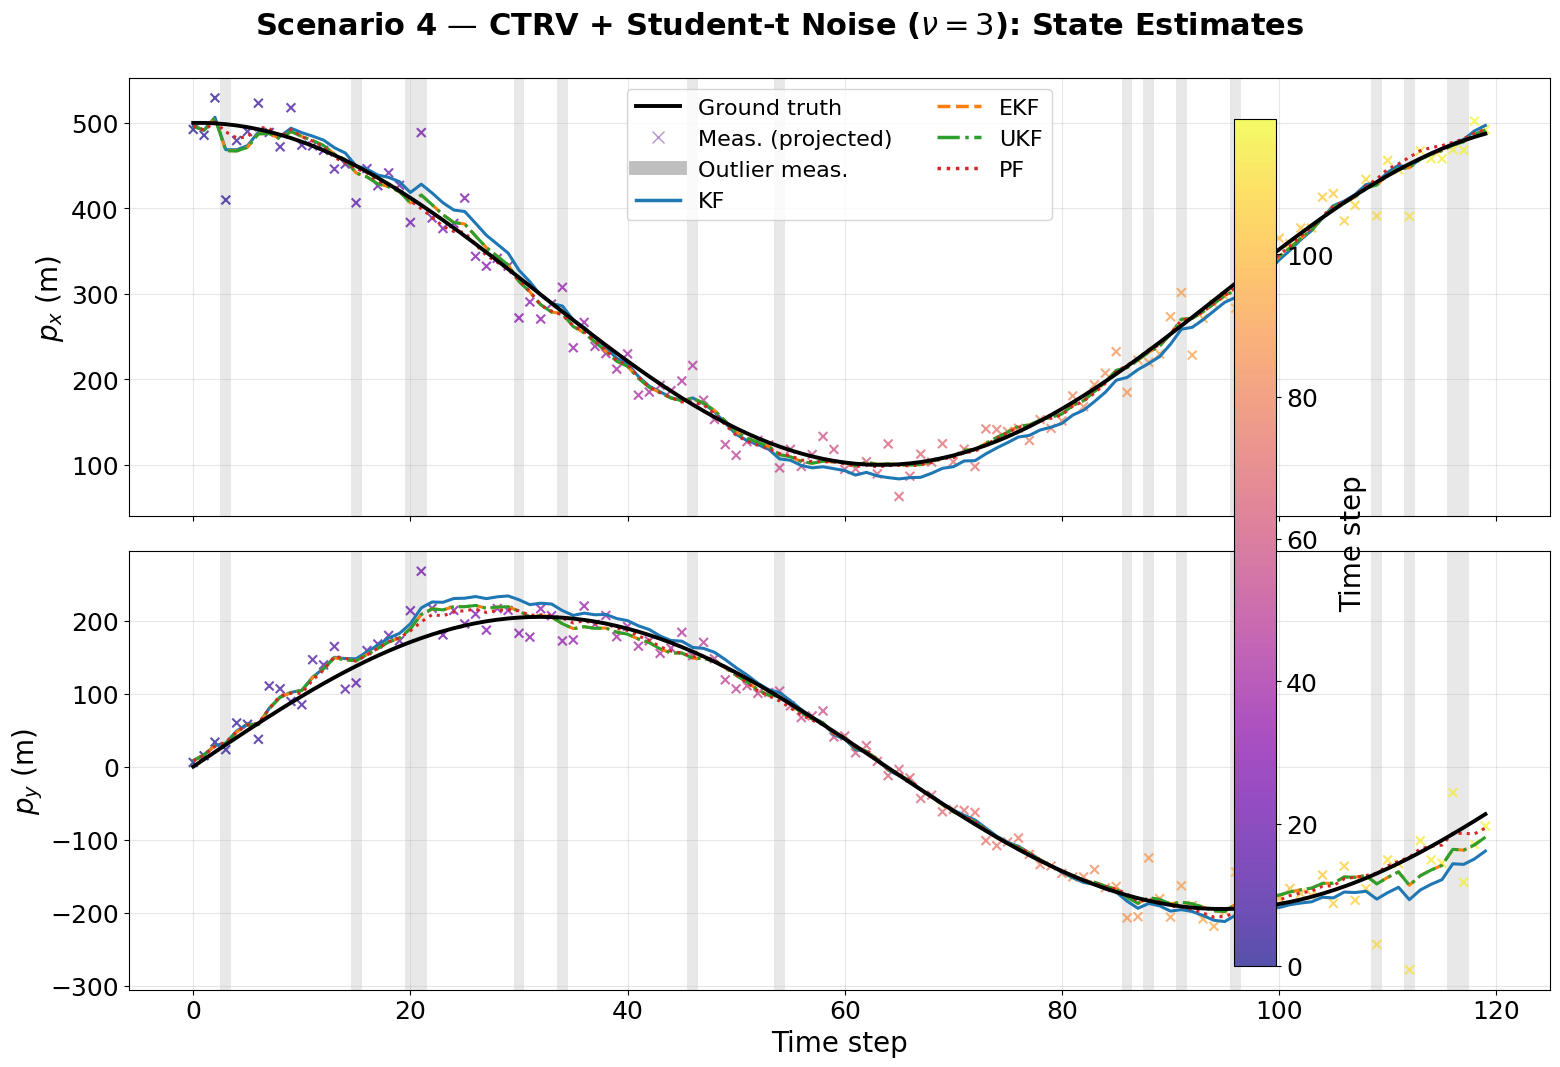

In [22]:
meas4_x = z4[:,0]*np.cos(z4[:,1])
meas4_y = z4[:,0]*np.sin(z4[:,1])

fig, axes = plt.subplots(2,1,figsize=(16,11),sharex=True)
for ax, dim, meas_vals, label in zip(
        axes,[0,1],[meas4_x,meas4_y],['$p_x$ (m)','$p_y$ (m)']):
    ax.plot(t4, true_states_4[:,dim], 'k-', lw=2.8, label='Ground truth', zorder=5)
    sc = plasma_scatter(ax, t4, meas_vals, label='Meas. (projected)')
    for k in outlier_steps_4:
        ax.axvspan(k-0.5,k+0.5,color='grey',alpha=0.18,lw=0)
    for f in FILTERS:
        ax.plot(t4, est4[f][:,dim], color=COLORS[f], ls=LSTYLE[f], lw=2.2, label=f, zorder=4)
    ax.set_ylabel(label); ax.grid(True,alpha=0.3)
    if dim==0:
        cb=add_colorbar(fig, sc, axes)
        extra=[Line2D([0],[0],color='k',lw=2.8,label='Ground truth'),
               Line2D([0],[0],marker='x',color='C4',ms=9,ls='',lw=1.5,alpha=0.7,
                      label='Meas. (projected)'),
               Line2D([0],[0],color='grey',alpha=0.5,lw=10,label='Outlier meas.')]
        ax.legend(handles=legend_handles(extra), ncol=2)
axes[-1].set_xlabel('Time step')
fig.suptitle(f'Scenario 4 — CTRV + Student-t Noise ($\\nu={NU4}$): State Estimates',
             fontweight='bold')
plt.tight_layout(); plt.savefig('figures/s4_state_estimates.png'); plt.show()


### Figure 9b — 2-D Trajectory (px vs py)

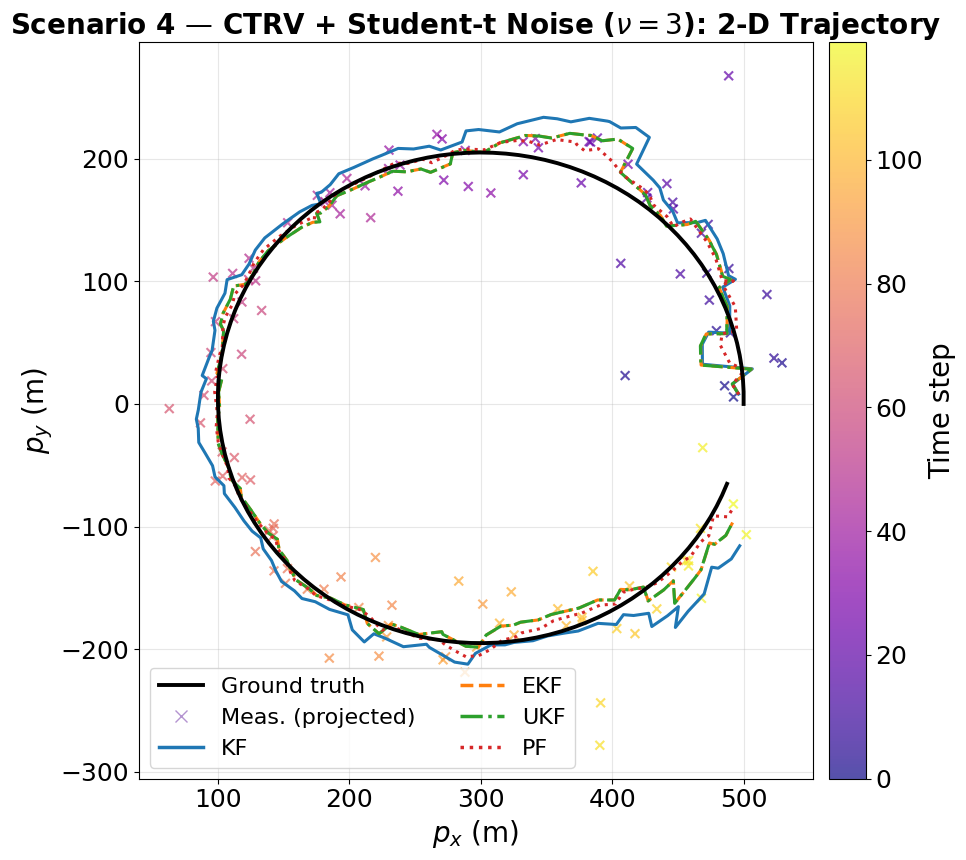

In [23]:
fig, ax = plt.subplots(figsize=(10,9))
ax.plot(true_states_4[:,0], true_states_4[:,1], 'k-', lw=2.8, label='Ground truth', zorder=5)
for k in outlier_steps_4:
    ax.axvspan(true_states_4[max(0,k-1),0], true_states_4[min(N4-1,k+1),0],
               color='grey', alpha=0.0, lw=0)  # no vspan on 2D; mark points instead
sc = plasma_scatter_2d(ax, meas4_x, meas4_y, t4, label='Meas. (projected)')
for f in FILTERS:
    ax.plot(est4[f][:,0], est4[f][:,1], color=COLORS[f], ls=LSTYLE[f], lw=2.2, label=f, zorder=4)
cb = fig.colorbar(sc, ax=ax, pad=0.02)
cb.set_label('Time step', fontsize=FS); cb.ax.tick_params(labelsize=FS_TICK)
extra=[Line2D([0],[0],color='k',lw=2.8,label='Ground truth'),
       Line2D([0],[0],marker='x',color='C4',ms=9,ls='',lw=1.5,alpha=0.7,
              label='Meas. (projected)')]
ax.legend(handles=legend_handles(extra), ncol=2)
ax.set_xlabel('$p_x$ (m)'); ax.set_ylabel('$p_y$ (m)')
ax.set_title(f'Scenario 4 — CTRV + Student-t Noise ($\\nu={NU4}$): 2-D Trajectory',
             fontweight='bold')
ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig('figures/s4_trajectory.png'); plt.show()


### Figure 10 — NEES Consistency

<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
/var/folders/2v/9n_l6bfd7y9f_1gmwjt3st900000gn/T/ipykernel_93971/4247976692.py:6: SyntaxWarning: invalid escape sequence '\c'
  label=f'{f} ({pct:.0f}% in $\chi^2_4$ bounds)')


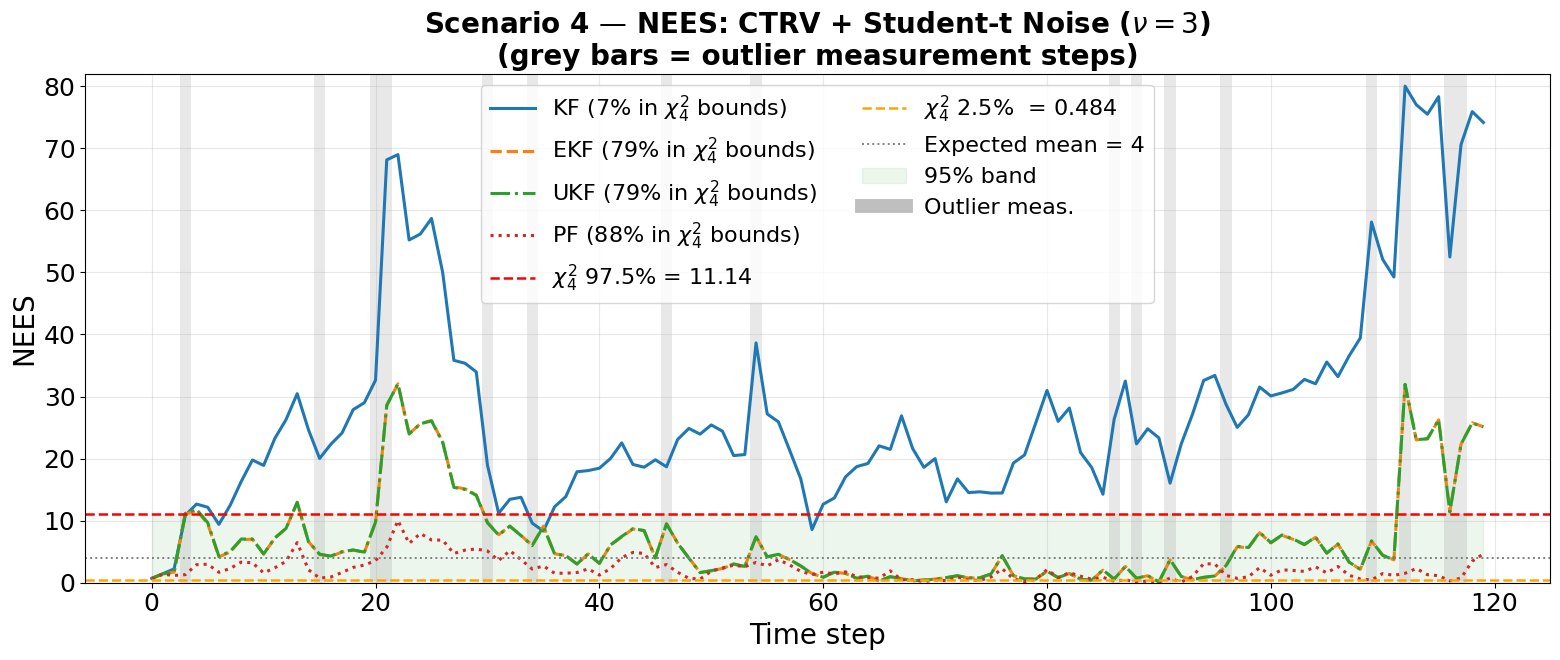

In [24]:
fig, ax = plt.subplots(figsize=(16,7))
for f in FILTERS:
    vals=np.clip(nees4[f],0,80)
    pct=np.mean((nees4[f]>=chi2_lo4)&(nees4[f]<=chi2_hi4))*100
    ax.plot(t4, vals, color=COLORS[f], ls=LSTYLE[f], lw=2.2,
            label=f'{f} ({pct:.0f}% in $\chi^2_4$ bounds)')
_add_chi2_bands(ax,t4,chi2_lo4,chi2_hi4,4)
for k in outlier_steps_4:
    ax.axvspan(k-0.5,k+0.5,color='grey',alpha=0.18,lw=0)
ax.plot([],[],color='grey',alpha=0.5,lw=10,label='Outlier meas.')
ax.set_xlabel('Time step'); ax.set_ylabel('NEES'); ax.set_ylim(0,82)
ax.set_title(
    f'Scenario 4 — NEES: CTRV + Student-t Noise ($\\nu={NU4}$)\n'
    '(grey bars = outlier measurement steps)', fontweight='bold')
ax.legend(ncol=2); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig('figures/s4_nees.png'); plt.show()


### Figure 11 — RMSE Comparison

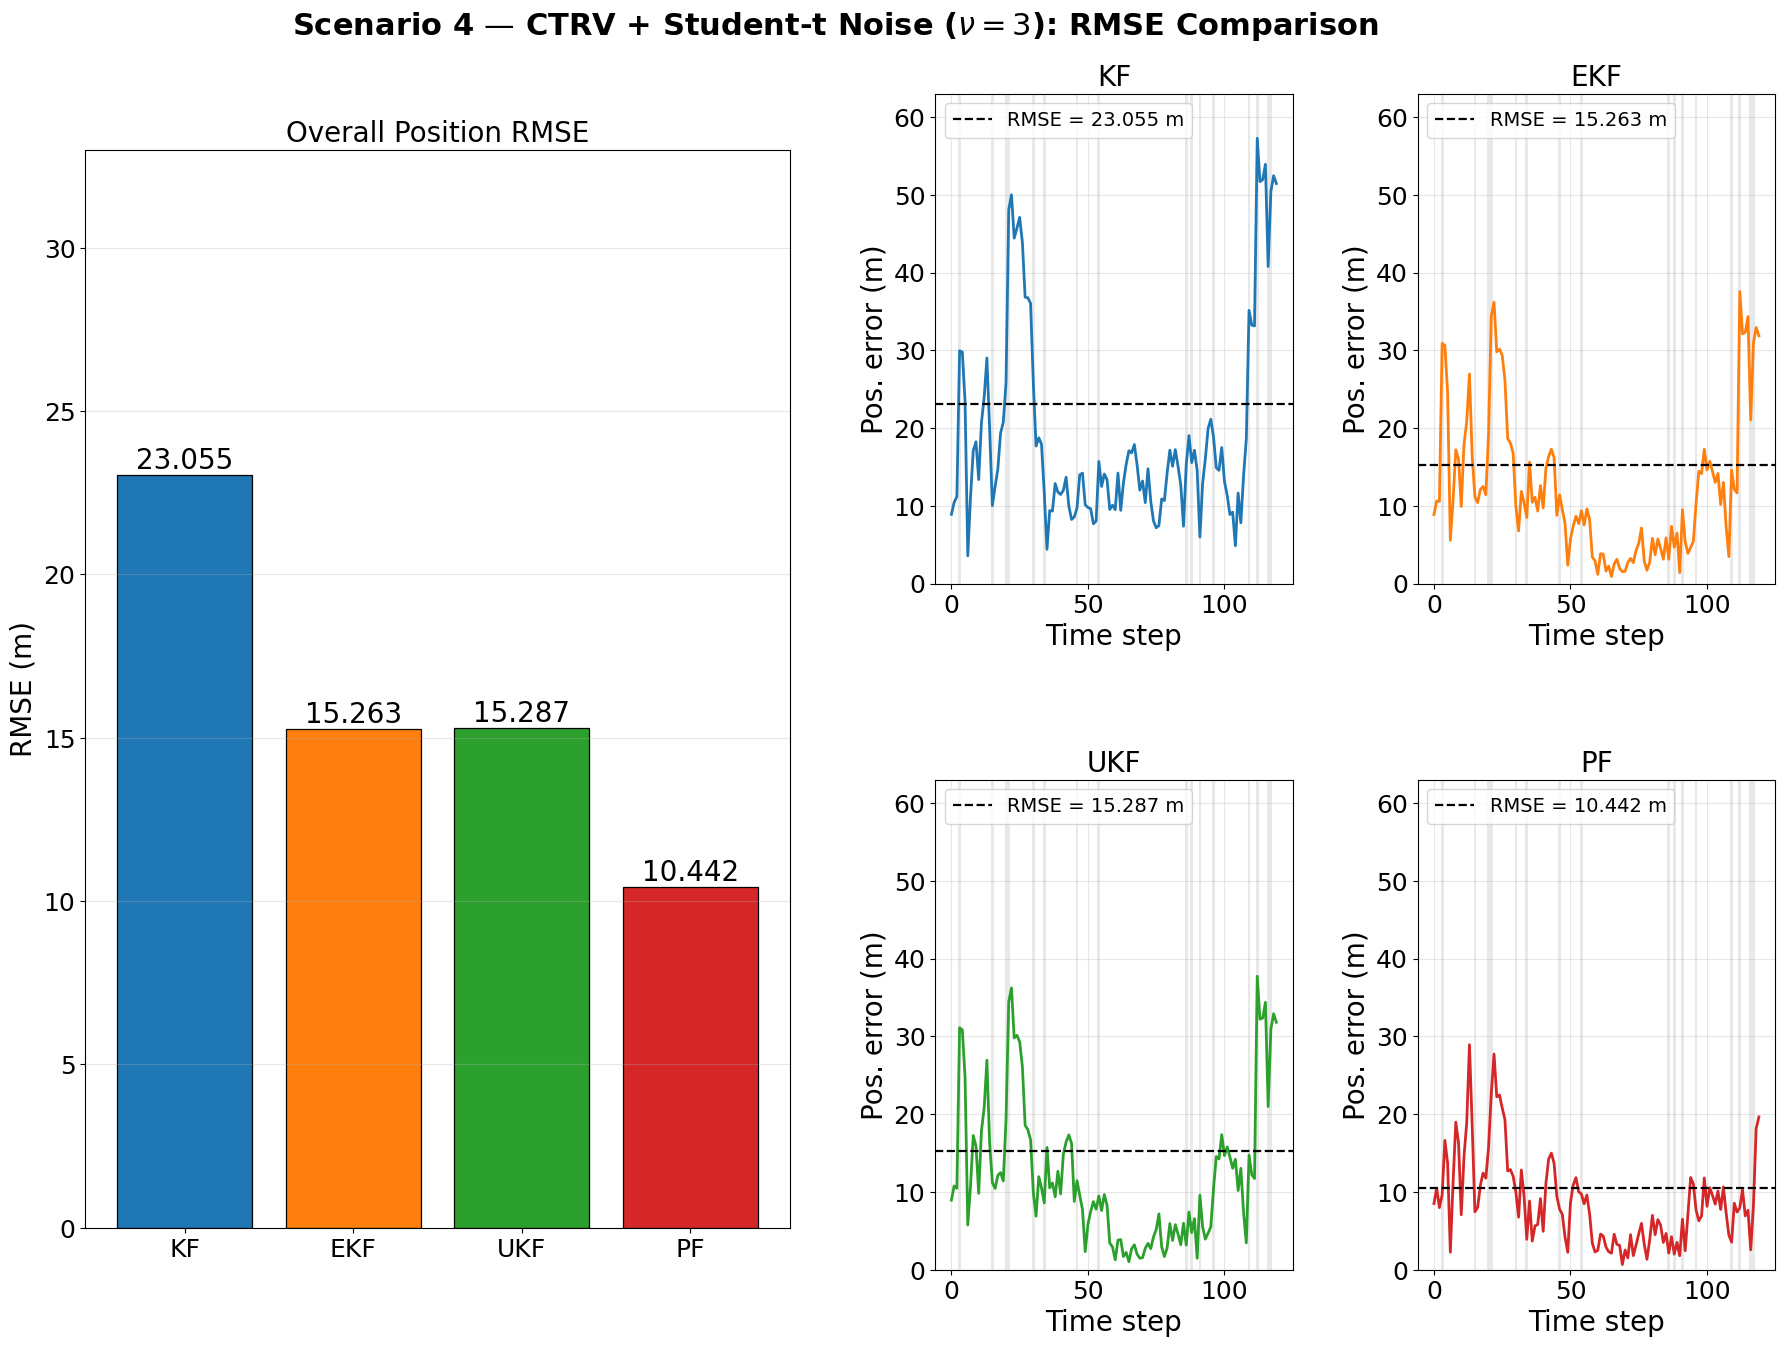

In [25]:
fig = plt.figure(figsize=(20, 14))

ax_bar = fig.add_subplot(1, 2, 1)
bars = ax_bar.bar(FILTERS, [overall4[f] for f in FILTERS],
                  color=[COLORS[f] for f in FILTERS], edgecolor='k', lw=0.9)
for bar, f in zip(bars, FILTERS):
    ax_bar.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{overall4[f]:.3f}', ha='center', va='bottom', fontsize=FS)
ax_bar.set_ylabel('RMSE (m)'); ax_bar.set_title('Overall Position RMSE')
ax_bar.grid(True, axis='y', alpha=0.3)
rmse_ylim = RMSE_S3S4_YLIM
ax_bar.set_ylim(0, rmse_ylim)

panel_ylim = max(pos_err_ts(est4[f], true_states_4).max() for f in FILTERS) * 1.1
gs_right = fig.add_gridspec(2, 2, left=0.55, right=0.97, top=0.92, bottom=0.08,
                              hspace=0.40, wspace=0.35)
for idx, f in enumerate(FILTERS):
    ax = fig.add_subplot(gs_right[idx//2, idx%2])
    err = pos_err_ts(est4[f], true_states_4)
    rmse_f = np.sqrt(np.mean(err**2))
    for k in outlier_steps_4:
        ax.axvspan(k-0.5, k+0.5, color='grey', alpha=0.18, lw=0)
    ax.plot(t4, err, color=COLORS[f], lw=2.0)
    ax.axhline(rmse_f, color='k', ls='--', lw=1.6, label=f'RMSE = {rmse_f:.3f} m')
    ax.set_title(f); ax.set_xlabel('Time step'); ax.set_ylabel('Pos. error (m)')
    ax.set_ylim(0, panel_ylim)
    ax.legend(fontsize=FS_LEG-2); ax.grid(True, alpha=0.3)

fig.suptitle(f'Scenario 4 — CTRV + Student-t Noise ($\\nu={NU4}$): RMSE Comparison',
             fontweight='bold')
plt.savefig('figures/s4_rmse.png'); plt.show()
